# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import spectral_norm
from torchvision.utils import save_image
from torch_fidelity import calculate_metrics

from sklearn.model_selection import train_test_split 
import numpy as np

import matplotlib.pyplot as plt

import datetime 
from tqdm import tqdm
import os, shutil


In [4]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE  = "cpu"
print(DEVICE)


cpu


In [3]:
base_path = "../Dataset"

dataset = base_path + "/s2-utm-33N-18E-242N-2018"
train_geojson_path = base_path + "/br-18E-242N-crop-labels-train-2018.geojson"

folder = "/DS3"
subfolder1 = "/Temporal Data"

data_path = dataset+folder
temporal_data_path = dataset+folder+subfolder1


In [2]:
def display_images(data_patches, show_timestap = True):
    for i in range(data_patches.shape[0]):
        patch = data_patches[i,...]
        indices = [patch[...,0:3], patch[...,:],]
        titles = ['RGB', 'RGB-NIR']

        fig, axs = plt.subplots(1, 2, figsize=(16, 4))
        for ax, idx_map, title in zip(axs, indices, titles):
            im = ax.imshow(idx_map, cmap='RdYlGn', vmin=-1, vmax=1)
            if show_timestap:
                title = title+f' - Timestamp {i} '
                ax.set_title(title)
            else:
                ax.set_title(title)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()



# Load Data

In [ ]:
# data_original = np.load((temporal_data_path+'/9_selected_time_range_filtered_data_27_day_majority60.npy'))
# data_augmented = np.load((temporal_data_path+'/12_selected_time_range_augumented_data_27_day.npy'))

# final_gan_data = np.empty((0, 27, 64, 64, 4))
# final_gan_labels = np.empty((0, 64, 64))

# majority_original_labels = np.load(temporal_data_path+'/10_selected_time_range_filtered_labels_27_day_majority60.npy')
# agumenmted_labels = np.load(temporal_data_path+'/8_agumented_labels.npy')

# final_gan_labels = np.concatenate((final_gan_labels, majority_original_labels), axis=0)
# final_gan_labels = np.concatenate((final_gan_labels, agumenmted_labels), axis=0)
# final_gan_labels = final_gan_labels.astype(np.int16)

# final_gan_data = np.concatenate((final_gan_data, data_original), axis=0)
# final_gan_data = np.concatenate((final_gan_data, data_augmented), axis=0)
# final_gan_data = final_gan_data.astype(np.float16)

# print(type(final_gan_data[0,0,0,0,0]))
# print(type(final_gan_labels[0,0,0]))

# np.save((temporal_data_path+'/14_final_TGAN_data.npy'), final_gan_data)
# np.save((temporal_data_path+'/15_final_TGAN_labels.npy'), final_gan_labels)


<class 'numpy.float16'>
<class 'numpy.int16'>


In [7]:
final_gan_data = np.load((temporal_data_path+'/14_final_TGAN_data.npy'))
final_gan_labels = np.load((temporal_data_path+'/15_final_TGAN_labels.npy'))
doy_list = np.load((temporal_data_path+'/13_selected_dates_DOY_normalised.npy'))

labels_upadated = np.where(final_gan_labels == -1, 0, final_gan_labels)
train_data, validation_data, train_labels, validation_labels = train_test_split(final_gan_data, labels_upadated, test_size=0.4, random_state= 2) 

# np.save((temporal_data_path+'/20_final_TGAN_train_data.npy'), train_data)
# np.save((temporal_data_path+'/21_final_TGAN_train_labels.npy'), train_labels)
# np.save((temporal_data_path+'/22_final_TGAN_validation_data.npy'), validation_data)
# np.save((temporal_data_path+'/23_final_TGAN_validation_labels.npy'), validation_labels)


In [6]:
print(final_gan_data.shape)
print(final_gan_labels.shape)
print(train_data.shape)
print(train_labels.shape)


(4403, 27, 64, 64, 4)
(4403, 64, 64)
(2641, 27, 64, 64, 4)
(2641, 64, 64)


# TGAN model

## Generator

In [8]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=4, dim_ff=512, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim_ff),
            nn.GELU(),
            nn.Linear(dim_ff, dim),
        )

    def forward(self, x):
        x_res = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x)
        x = x + x_res

        x_res = x
        x = self.norm2(x)
        x = self.ff(x) + x_res
        return x
    
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
            nn.ReLU(),
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
        )

    def forward(self, x):
        return x + self.block(x)
    
class UNetTransformerGenerator(nn.Module):
    def __init__(self, in_channels=14, out_channels=4, emb_dim=512, num_heads=8, depth=4):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, 64, 3, padding=1)), 
            nn.ReLU(),
            spectral_norm(nn.Conv2d(64, 64, 3, padding=1)), 
            nn.ELU(),
            ResidualBlock(64)
        )
        self.enc2 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(64, 128, 3, padding=1)),
            nn.GELU(),
            ResidualBlock(128)
        )
        self.enc3 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(128, 256, 3, padding=1)),
            nn.ReLU(),
            ResidualBlock(256)
        )
        self.enc4 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(256, emb_dim, 3, padding=1)),  # 512 default
            nn.GELU(),
            ResidualBlock(emb_dim)
        )

        # Transformer
        self.flatten = nn.Flatten(2)
        self.transformers = nn.Sequential(*[
            TransformerBlock(emb_dim, heads=num_heads) for _ in range(depth)
        ])
        self.unflatten = lambda x: x.view(x.size(0), emb_dim, 8, 8)

        # Decoder
        self.dec4 = nn.Sequential(
            ResidualBlock(emb_dim),
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(emb_dim, 256, 3, padding=1)),
            nn.ReLU()
        )
        self.dec3 = nn.Sequential(
            ResidualBlock(512),  # 256 from dec4 + 256 from enc3
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(512, 128, 3, padding=1)),
            nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            ResidualBlock(256),  # 128 + 128
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(256, 64, 3, padding=1)),
            nn.ReLU()
        )
        self.dec1 = nn.Sequential(
            ResidualBlock(128),  # 64 + 64
            spectral_norm(nn.Conv2d(128, out_channels, 3, padding=1)),
            nn.Tanh()
        )

    def forward(self, noise, label_map):
        x = torch.cat([noise, label_map], dim=1)  # [B, 14, 64, 64]

        e1 = self.enc1(x)        # [B, 64, 64, 64]
        e2 = self.enc2(e1)       # [B, 128, 32, 32]
        e3 = self.enc3(e2)       # [B, 256, 16, 16]
        e4 = self.enc4(e3)       # [B, 512, 8, 8]

        x_flat = self.flatten(e4).permute(0, 2, 1)  # [B, 64, 512]
        x_trans = self.transformers(x_flat)
        x_unflat = self.unflatten(x_trans.permute(0, 2, 1))  # [B, 512, 8, 8]

        d4 = self.dec4(x_unflat)                         # [B, 256, 16, 16]
        d3 = self.dec3(torch.cat([d4, e3], dim=1))       # [B, 128, 32, 32]
        d2 = self.dec2(torch.cat([d3, e2], dim=1))       # [B, 64, 64, 64]
        d1 = self.dec1(torch.cat([d2, e1], dim=1))       # [B, out_channels, 64, 64]

        return d1


## Discriminator

In [9]:
class DiscriminatorWithLabelEmbedding(nn.Module):
    def __init__(self, in_channels=4, label_classes=10, base_channels=64):
        super().__init__()

        self.img_conv = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 4, 2, 1),  # [B, 64, 32, 32]
            nn.LeakyReLU(0.2)
        )

        self.label_embed = nn.Sequential(
            nn.Conv2d(label_classes, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2)
        )

        # Save layers individually to extract features
        self.conv1 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, 4, 2, 1),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.final = nn.Conv2d(base_channels * 4, 1, 8)  # [B, 1, 1, 1]

    def forward(self, img, label_map):
        label_map = label_map.float()
        img_feat = self.img_conv(img.float())           # [B, 64, 32, 32]
        label_feat = self.label_embed(label_map)        # [B, 64, 32, 32]
        x = torch.cat([img_feat, label_feat], dim=1)    # [B, 128, 32, 32]

        feats = []

        x = self.conv1(x)        
        feats.append(x.mean([2, 3]))  # Global avg pooled features

        x = self.conv2(x)
        feats.append(x.mean([2, 3]))

        out = self.final(x)               # [B, 1, 1, 1]
        out = out.view(-1, 1)

        return out, feats


In [10]:
# ---------- Temporal Controller: produces per-time noise maps ----------
class TemporalNoiseGenerator(nn.Module):
    """
    G^t: given a global latent z0 and simple time embeddings (sin/cos),
    generate a sequence of noise maps [B, T, 4, 64, 64] to drive the spatial G.
    """
    def __init__(self, noise_dim=128, time_feat_dim=16, out_channels=4,
                 base_ch=256, init_spatial=8):
        super().__init__()
        self.noise_dim = noise_dim
        self.time_in = nn.Linear(2, time_feat_dim)  # 2 = sin/cos
        self.rnn = nn.GRU(input_size=noise_dim + time_feat_dim,
                           hidden_size=noise_dim,
                           num_layers=1, batch_first=True, bidirectional=False)

        # map per-time latent -> small spatial tensor then upsample to 64x64
        self.proj = nn.Linear(noise_dim, base_ch * init_spatial * init_spatial)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_ch, base_ch//2, 4, 2, 1),  # 8->16
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(base_ch//2, base_ch//4, 4, 2, 1),  # 16->32
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(base_ch//4, out_channels, 4, 2, 1),  # 32->64
            nn.Tanh()  # keep noise in [-1, 1]
        )
        self.init_spatial = init_spatial
        self.base_ch = base_ch

    @torch.no_grad()
    def _time_sin_cos(self, doy_list, device):
        # normalized time indices 0..T-1 -> sin/cos features
        t = torch.tensor(doy_list).float().to(device)
        phase = 2.0 * torch.pi * t 
        return torch.stack([torch.sin(phase), torch.cos(phase)], dim=-1)  # [T,2]

    def forward(self, B, T, doy_list, device):
        # global latent z0 per sample
        z0 = torch.randn(B, self.noise_dim, device=device)
        #print("latent vector created")

        # time embeddings
        time_sc = self._time_sin_cos(doy_list, device)               # [T,2]
        time_feat = self.time_in(time_sc).unsqueeze(0).repeat(B, 1, 1)  # [B,T,tf]
        #print("time embeddings ready")

        # repeat z0 across time and concatenate with time features
        z_seq = z0.unsqueeze(1).repeat(1, T, 1)               # [B,T,noise_dim]
        rnn_in = torch.cat([z_seq, time_feat], dim=-1)        # [B,T,noise_dim+tf]
        #print("combining latent vector and time sequence")

        # temporal evolution
        h_seq, _ = self.rnn(rnn_in)                           # [B,T,noise_dim]
        #print("completed rnn")

        # per-time decoding to noise maps
        x = self.proj(h_seq)                                  # [B,T,base*8*8]
        x = x.view(B*T, self.base_ch, self.init_spatial, self.init_spatial)
        #print("data prepared for noise maps")
        noise_maps = self.decoder(x)                          # [B*T,4,64,64]
        noise_maps = noise_maps.view(B, T, 4, 64, 64)
        return noise_maps


# ---------- Temporal Sequence Discriminator: operates on per-frame features ----------
class TemporalDiscriminator(nn.Module):
    """
    D^t: consumes a sequence of per-frame features [B, T, F] and outputs [B,1].
    Use features coming from D^s (your spatial discriminator).
    """
    def __init__(self, feat_dim=384, hidden=256, layers=1, bidir=True):
        super().__init__()
        self.rnn = nn.GRU(feat_dim, hidden, num_layers=layers,
                          batch_first=True, bidirectional=bidir)
        out_dim = hidden * (2 if bidir else 1)
        self.fc = nn.Linear(out_dim, 1)

    def forward(self, feat_seq):  # [B,T,F]
        h, _ = self.rnn(feat_seq)           # [B,T,H*dir]
        # use last time step (or mean pool over time)
        h_last = h[:, -1, :]                # [B,H*dir]
        logit = self.fc(h_last)             # [B,1]
        return logit


In [ ]:
class SequentialGeneratorWrapper(nn.Module):
    """
    Wraps your existing UNetTransformerGenerator (G^s) and a new TemporalNoiseGenerator (G^t).
    Forward returns a full sequence of frames: [B,T,4,64,64].
    """
    def __init__(self, spatial_generator: nn.Module, temporal_noise: TemporalNoiseGenerator):
        super().__init__()
        self.Gs = spatial_generator
        self.Gt = temporal_noise
    
    def fetch_temporal_generator(self):
        return self.Gt
    
    def fetch_spatial_generator(self):
        return self.Gs    

    def forward(self, one_hot_label_map, T, doy_list):
        """
        one_hot_label_map: [B, C_label, H, W]  (static over time)
        returns: fake_seq [B, T, 4, 64, 64]
        """
        B = one_hot_label_map.size(0)
        device = one_hot_label_map.device
        noise_seq = self.Gt(B, T, doy_list,  device)                     # [B,T,4,64,64]
        #print("noise maps ready")

        # Render frames with Gs. vectorize by flattening BT
        BT, C, H, W = B*T, noise_seq.size(2), 64, 64
        noise_bt = noise_seq.view(BT, C, H, W)
        labels_bt = one_hot_label_map.unsqueeze(1).repeat(1, T, 1, 1, 1).view(BT, -1, H, W)
        #print(f"data prepared for spatial gen. {noise_bt.shape} {labels_bt.shape}")
        fake_bt = self.Gs(noise_bt, labels_bt)                # [BT,4,64,64]
        fake_seq = fake_bt.view(B, T, 4, H, W)
        #print("generated image is ready")
        return fake_seq


## Helper functions

In [12]:
def load_models(Gs, Gt, Ds, Dt, G_optimizer, Ds_optimizer, D_optimizer_t, path):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
    
    Gs.load_state_dict(checkpoint['generator_spatial_state_dict'])
    Gt.load_state_dict(checkpoint['generator_temporal_state_dict'])
    Ds.load_state_dict(checkpoint['discriminator_spatial_state_dict'])
    Dt.load_state_dict(checkpoint['discriminator_temporal_state_dict'])

    G_optimizer.load_state_dict(checkpoint['g_optimizer_spatial_state_dict'])

    Ds_optimizer.load_state_dict(checkpoint['d_optimizer_spatial_state_dict'])
    D_optimizer_t.load_state_dict(checkpoint['d_optimizer_temporal_state_dict'])
    
    epoch = checkpoint.get('epoch', 0)
    print(f"Models loaded from {path} (Epoch {epoch})")
    return epoch

def save_models(Gs, Gt, Ds, Dt, G_optimizer, Ds_optimizer, D_optimizer_t, epoch, path, modelid=0):
    epoch+=1

    filename = r'/acgan_checkpoint-Model '+str(modelid)+r'-Epoch '+str(epoch)+r'_'+ str(datetime.date.today()) +r'.pth'
    full_path = path + filename
    #print(full_path)

    torch.save({
        'epoch': epoch,
        'generator_spatial_state_dict': Gs.state_dict(),
        'generator_temporal_state_dict': Gt.state_dict(),
        'discriminator_spatial_state_dict': Ds.state_dict(),
        'discriminator_temporal_state_dict': Dt.state_dict(),
        'g_optimizer_spatial_state_dict': G_optimizer.state_dict(),
        'd_optimizer_spatial_state_dict': Ds_optimizer.state_dict(),
        'd_optimizer_temporal_state_dict': D_optimizer_t.state_dict(),
    }, full_path)
    
    print(f"Models saved to {full_path}")


## Training loop

In [12]:
def train_tgan_sequential(Gs, 
                          Ds, 
                          Gt, 
                          Dt, 
                          g_optimizer, 
                          d_optimizer, 
                          d_optimizer_t,
                          dataloader,
                          doy_list, 
                          epochs, 
                          num_classes=10,
                          modelid=1, 
                          gen_iter=1,
                          w_adv_spatial=1.0,
                          w_adv_temporal=0.5,
                          w_featmatch=0.1, 
                          w_recon=25.0, 
                          w_smooth=2.0,
                          freeze_spatial_epochs = 0
                          ):
    T = 27

    loss_bce = nn.BCEWithLogitsLoss()
    losses_g, losses_d = [], []

    # Wrapper to generate sequences
    G = SequentialGeneratorWrapper(Gs, Gt).to(DEVICE)

    for epoch in range(epochs): 
        if epoch == 0:
            print("Test Save")
            save_models(G.fetch_spatial_generator(), 
                        G.fetch_temporal_generator(),
                        Ds,          
                        Dt,            
                        g_optimizer,
                        d_optimizer,
                        d_optimizer_t,
                        epoch, 
                        modelid=modelid, 
                        path=r'../GAN models/Spatial models/NIR - based/Temporal'
                        )
            print("Test Save Successful")
        g_epoch, d_epoch = 0.0, 0.0

        if epoch < freeze_spatial_epochs:
            for p in Gs.parameters():
                p.requires_grad_(False)
        else:
            for p in Gs.parameters():
                p.requires_grad_(True)

        batch_counter = 1
        for real_seq, labels in dataloader:
            print(f"Epoch: {epoch} | Batch Number: {batch_counter}")
            batch_counter +=1
            # real sequences
            real_seq = real_seq.to(DEVICE).float()    # [B,T,4,64,64]
            labels = labels.to(DEVICE).long()         # [B,64,64]
            B = real_seq.size(0)

            # one-hot label map (static over time)
            one_hot = F.one_hot(labels, num_classes=num_classes).permute(0,3,1,2).float()  # [B,C_label,64,64]

            # ---------- Train Ds (spatial, per frame) ----------
            with torch.no_grad():
                fake_seq = G(one_hot, T, doy_list)  # [B,T,4,64,64]

            real_bt = real_seq.view(B*T, 4, 64, 64)
            fake_bt = fake_seq.view(B*T, 4, 64, 64)
            label_bt = one_hot.unsqueeze(1).repeat(1, T, 1, 1, 1).view(B*T, -1, 64, 64)

            # soft labels
            real_targets = torch.empty(B*T, 1, device=DEVICE).uniform_(0.9, 1.0)
            fake_targets = torch.empty(B*T, 1, device=DEVICE).uniform_(0.0, 0.1)

            #print("Training spatial discriminator")

            d_real, _ = Ds(real_bt, label_bt)
            d_fake, _ = Ds(fake_bt, label_bt)

            # occasional flip for regularization
            if torch.rand(1).item() < 0.1:
                real_targets, fake_targets = fake_targets, real_targets

            d_loss = loss_bce(d_real, real_targets) + loss_bce(d_fake, fake_targets)

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # ---------- Train Dt (temporal) ----------
            #print("Training temporal discriminator")
            with torch.no_grad():
                _, real_feats_bt = Ds(real_bt, label_bt)  # list-> feats already pooled
                real_feats_bt = torch.cat(real_feats_bt, dim=1)  # [B*T,F]
                _, fake_feats_bt = Ds(fake_bt, label_bt)
                fake_feats_bt = torch.cat(fake_feats_bt, dim=1)

            real_feat_seq = real_feats_bt.view(B, T, -1)  # [B,T,F]
            fake_feat_seq = fake_feats_bt.view(B, T, -1)

            real_seq_targets = torch.empty(B, 1, device=DEVICE).uniform_(0.9, 1.0)
            fake_seq_targets = torch.empty(B, 1, device=DEVICE).uniform_(0.0, 0.1)

            dt_real = Dt(real_feat_seq)
            dt_fake = Dt(fake_feat_seq)

            d_loss_t = loss_bce(dt_real, real_seq_targets) + loss_bce(dt_fake, fake_seq_targets)

            d_optimizer_t.zero_grad()
            d_loss_t.backward()
            d_optimizer_t.step()

            # ---------- Train G (Gs + Gt) ----------
            g_iter_loss_accum = 0.0
            for iteration in range(gen_iter):
                #print(f"Training generator, iteration number: {iteration}")
                fake_seq = G(one_hot, T, doy_list) 
                
                #print("executed generator")                       # [B,T,4,64,64]
                fake_bt = fake_seq.view(B*T, 4, 64, 64)

                #print("sending to discriminator")
                g_pred_s, fake_feats_bt = Ds(fake_bt, label_bt)   # per-frame logits & feats
                g_targets_s = torch.ones(B*T, 1, device=DEVICE)
                adv_spatial = loss_bce(g_pred_s, g_targets_s)

                #print(f"feature matching (compare to current real batch)")
                with torch.no_grad():
                    _, real_feats_bt = Ds(real_bt, label_bt)
                real_feats_bt = torch.cat(real_feats_bt, dim=1)
                fake_feats_bt = torch.cat(fake_feats_bt, dim=1)

                feat_match = F.l1_loss(fake_feats_bt, real_feats_bt)

                #print(f"temporal adversarial (sequence level)")
                fake_feat_seq = fake_feats_bt.view(B, T, -1)
                g_pred_t = Dt(fake_feat_seq)
                g_targets_t = torch.ones(B, 1, device=DEVICE)
                adv_temporal = loss_bce(g_pred_t, g_targets_t)

                # reconstruction (paired supervision)
                #print("Calculate recon loss")
                recon = F.l1_loss(fake_seq, real_seq)

                #print("temporal smoothness (TV over time)")
                tv_t = torch.mean(torch.abs(fake_seq[:, 1:] - fake_seq[:, :-1]))

                #print("Total loss")
                g_loss = (w_adv_spatial * adv_spatial
                          + w_adv_temporal * adv_temporal
                          + w_featmatch * feat_match
                          + w_recon * recon
                          + w_smooth * tv_t)

                
                #print("optimisers")
                g_optimizer.zero_grad()
                g_loss.backward()
                g_optimizer.step()
                g_iter_loss_accum += g_loss.item()

            g_epoch += g_iter_loss_accum / gen_iter
            d_epoch += (d_loss.item() + d_loss_t.item())

        avg_g = g_epoch / len(dataloader)
        avg_d = d_epoch / len(dataloader)
        print(f"[Epoch {epoch+1}] D: {avg_d:.4f} | G: {avg_g:.4f}")

        losses_g.append(avg_g)
        losses_d.append(avg_d)

        if ((epoch+1)%1) == 0:
            print("")
            save_models(G.fetch_spatial_generator(), 
                        G.fetch_temporal_generator(),
                        Ds,          
                        Dt,            
                        g_optimizer,
                        d_optimizer,
                        d_optimizer_t,
                        epoch, 
                        modelid=modelid, 
                        path=r'../GAN models/Spatial models/NIR - based/Temporal'
                        )
            print("")

    return losses_g, losses_d


In [14]:
class ImageLabelDataset(Dataset):
    def __init__(self, image_array, label_array):
        self.images = torch.tensor(image_array, dtype=torch.float32)  # (N, 4, 64, 64)
        self.labels = torch.tensor(label_array, dtype=torch.float32)  # (N, 1, 64, 64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]



In [13]:
image_data = np.transpose(train_data, (0, 1, 4, 2, 3))  # (N, T, 4, 64, 64)

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

generator_temporal = TemporalNoiseGenerator().to(DEVICE)
discriminator_temporal= TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
generator_spatial = UNetTransformerGenerator(depth=8).to(DEVICE)
discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_params = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
g_optimizer = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

losses_g, losses_d = train_tgan_sequential(generator_spatial, 
                                           discriminator_spatial, 
                                           generator_temporal,
                                           discriminator_temporal,  
                                           g_optimizer, 
                                           d_optimizer, 
                                           d_optimizer_t, 
                                           loader, 
                                           doy_list,
                                           epochs=10, 
                                           modelid=2, 
                                           gen_iter=5)


Test Save
Models saved to ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 2-Epoch 1_2025-09-11.pth
Test Save Successful
Epoch: 0 | Batch Number: 1
Epoch: 0 | Batch Number: 2
Epoch: 0 | Batch Number: 3
Epoch: 0 | Batch Number: 4
Epoch: 0 | Batch Number: 5
Epoch: 0 | Batch Number: 6
Epoch: 0 | Batch Number: 7
Epoch: 0 | Batch Number: 8
Epoch: 0 | Batch Number: 9
Epoch: 0 | Batch Number: 10
Epoch: 0 | Batch Number: 11
Epoch: 0 | Batch Number: 12
Epoch: 0 | Batch Number: 13
Epoch: 0 | Batch Number: 14
Epoch: 0 | Batch Number: 15
Epoch: 0 | Batch Number: 16
Epoch: 0 | Batch Number: 17
Epoch: 0 | Batch Number: 18
Epoch: 0 | Batch Number: 19
Epoch: 0 | Batch Number: 20
Epoch: 0 | Batch Number: 21
Epoch: 0 | Batch Number: 22
Epoch: 0 | Batch Number: 23
Epoch: 0 | Batch Number: 24
Epoch: 0 | Batch Number: 25
Epoch: 0 | Batch Number: 26
Epoch: 0 | Batch Number: 27
Epoch: 0 | Batch Number: 28
Epoch: 0 | Batch Number: 29
Epoch: 0 | Batch Number: 30
Epoch: 0 | Batch Number:

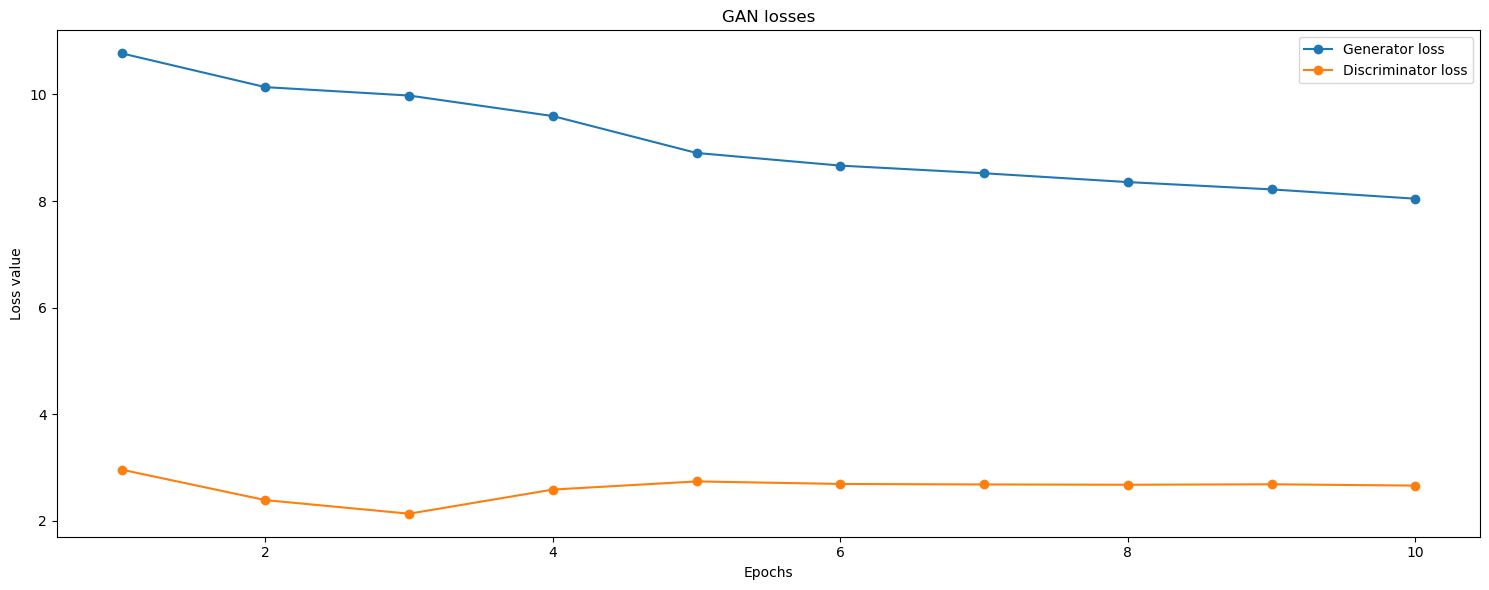

In [14]:
temporal_loss_array = np.array([losses_g, losses_d])
np.save('./temporal_GAN_losses_model2.npy',temporal_loss_array)

figure = plt.figure(figsize=(15,6))

titles = ['Generator loss', 'Discriminator loss']

plt.plot(range(1,(temporal_loss_array.shape[1]+1)), temporal_loss_array[0], label=titles[0], marker='o')
plt.plot(range(1,(temporal_loss_array.shape[1]+1)), temporal_loss_array[1], label=titles[1], marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss value')
plt.title('GAN losses')
plt.legend()

plt.tight_layout()
plt.show()


In [45]:
# model_data = {
#     "id": 2,              # Integer value 
#     "start_epoch": 1,    # Integer
#     "end_epoch": 10,     # Integer
#     "depth": 8,           # No of layers,
#     "interval": 1,       # Model save frequency in epochs
#     "best_model": 10,     # Based on loss curves along with FID and KID scores 
#     "date": "2025-09-16", # Format: YYYY-MM-DD # Best model date
# }

model_data = {
    "id": 1,              # Integer value 
    "start_epoch": 1,    # Integer
    "end_epoch": 10,     # Integer
    "depth": 4,           # No of layers,
    "interval": 1,       # Model save frequency in epochs
    "best_model": 10,     # Based on loss curves along with FID and KID scores 
    "date": "2025-09-18", # Format: YYYY-MM-DD # Best model date
}

selected_model_path = "../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model "+ str(model_data["id"]) +"-Epoch "+str(model_data["best_model"])+"_"+model_data["date"]+".pth"


In [46]:
selected_model_path


'../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 1-Epoch 10_2025-09-18.pth'

In [ ]:
generator_temporal  = TemporalNoiseGenerator().to(DEVICE)
discriminator_temporal = TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
generator_spatial   = UNetTransformerGenerator(depth=model_data["depth"]).to(DEVICE)
discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_params      = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
g_optimizer   = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
d_optimizer   = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

_ = load_models(generator_spatial,
                generator_temporal,
                discriminator_spatial,
                discriminator_temporal,
                g_optimizer,
                d_optimizer,
                d_optimizer_t,
                selected_model_path)

image_data = np.transpose(validation_data, (0, 1, 4, 2, 3))  # (N, T, 4, 64, 64)

dataset = ImageLabelDataset(image_data, validation_labels)
loader = DataLoader(dataset, batch_size=8, shuffle=True)


Models loaded from ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 1-Epoch 10_2025-09-18.pth (Epoch 10)


# Visualisation

------------------------- Timestamp: 0 -------------------------
Original Image


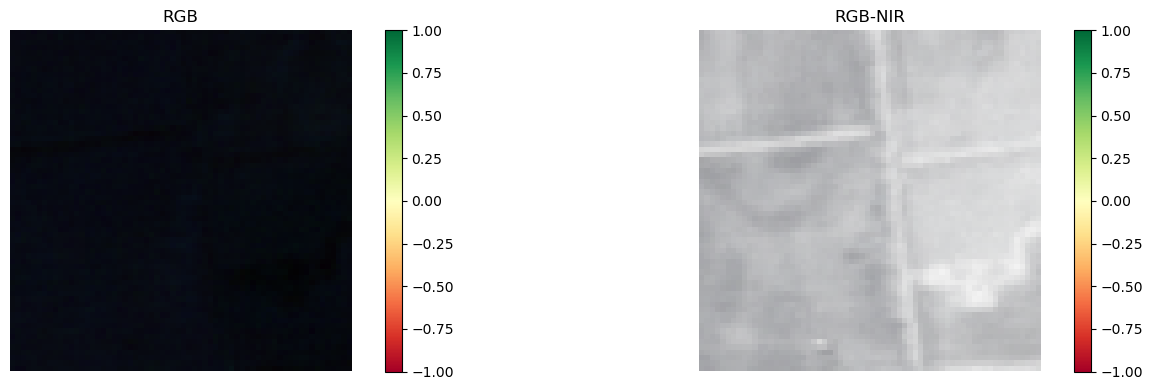

GAN Image


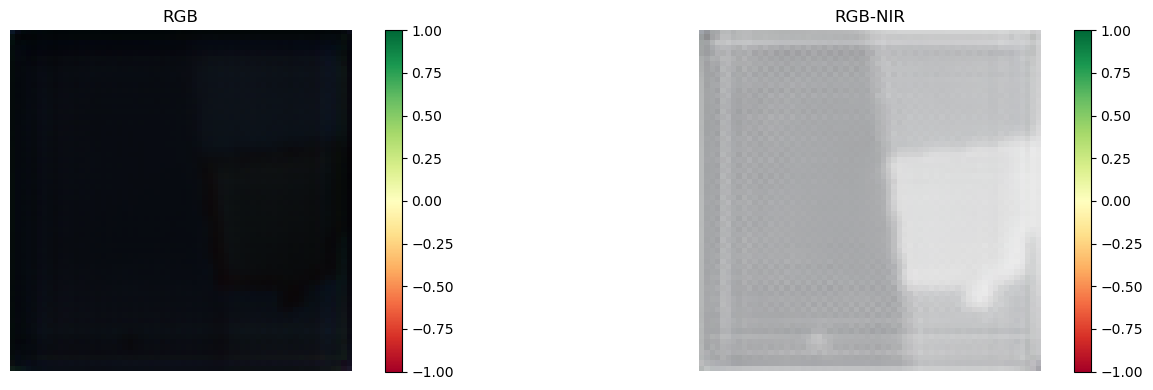

------------------------- Timestamp: 1 -------------------------
Original Image


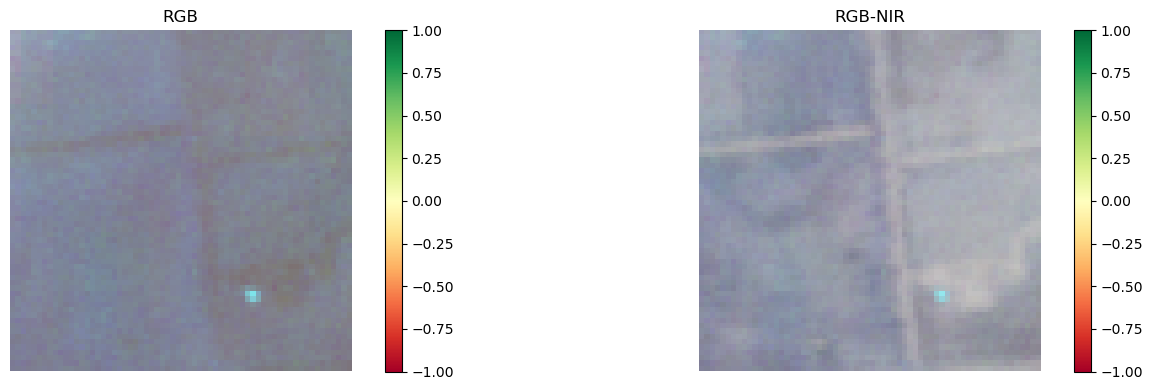

GAN Image


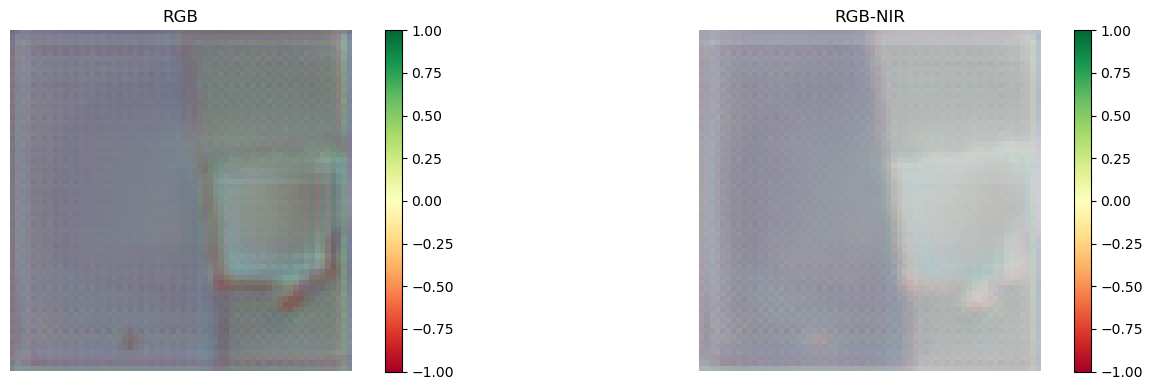

------------------------- Timestamp: 2 -------------------------
Original Image


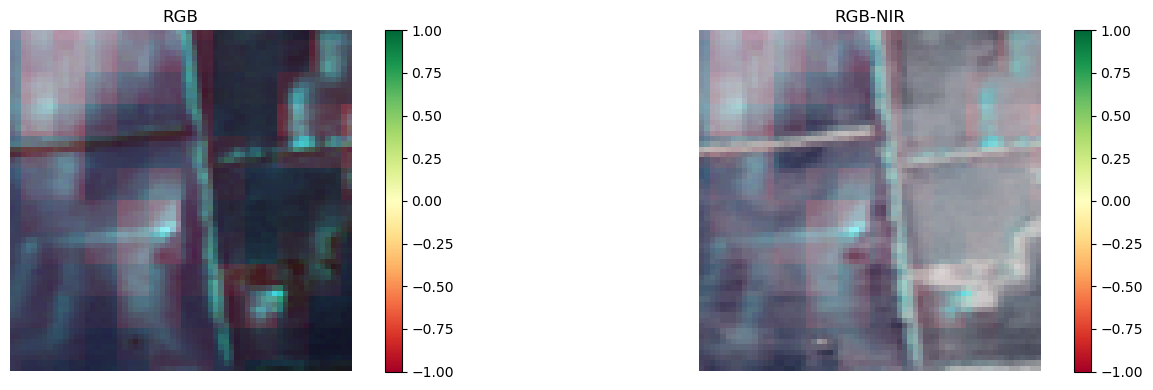

GAN Image


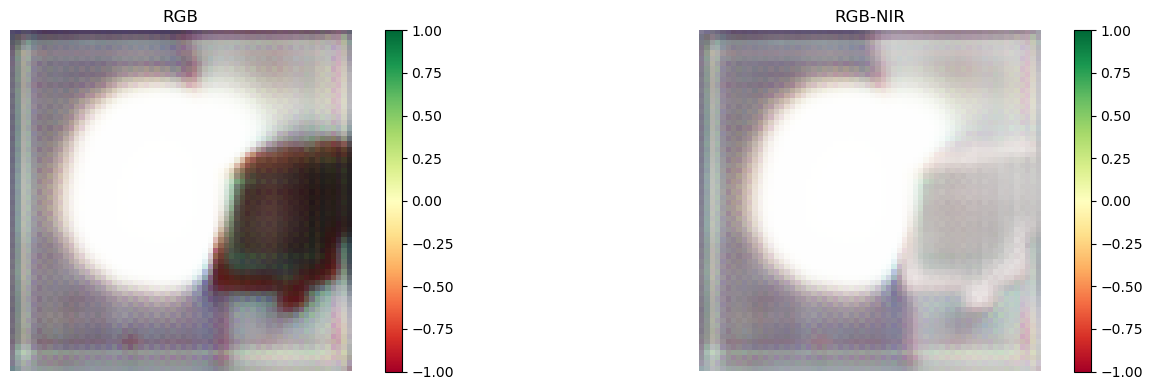

------------------------- Timestamp: 3 -------------------------
Original Image


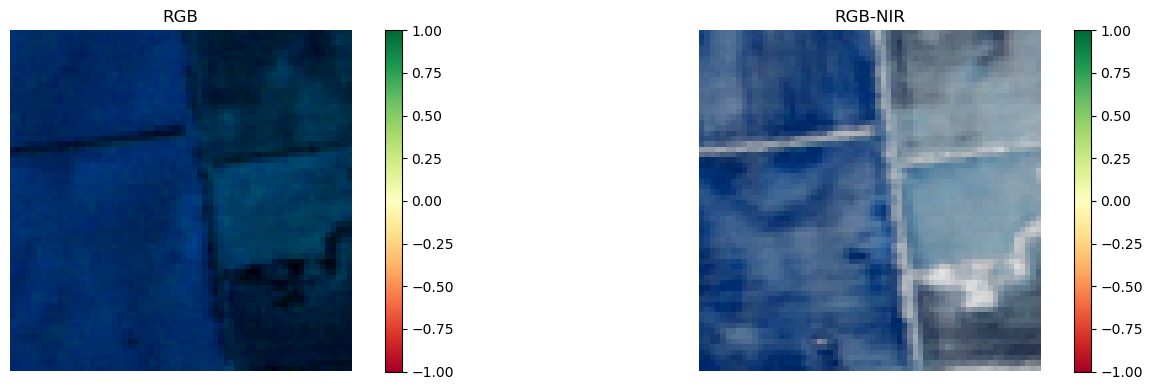

GAN Image


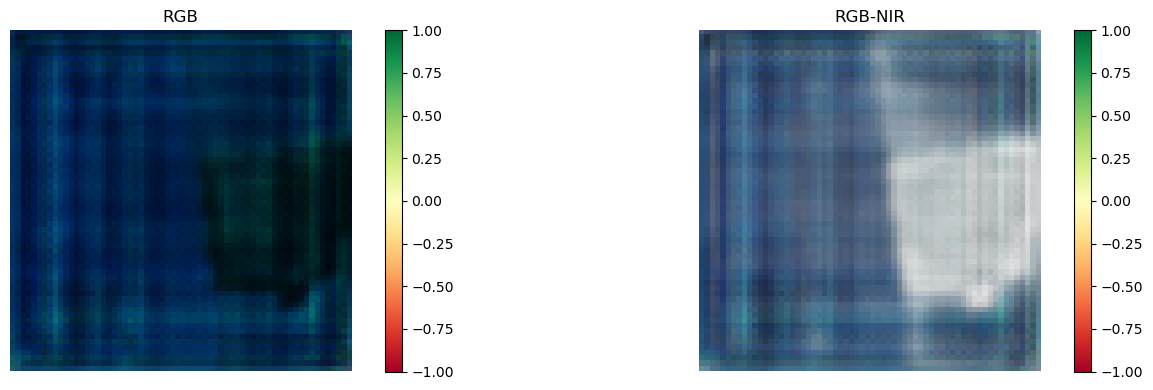

------------------------- Timestamp: 4 -------------------------
Original Image


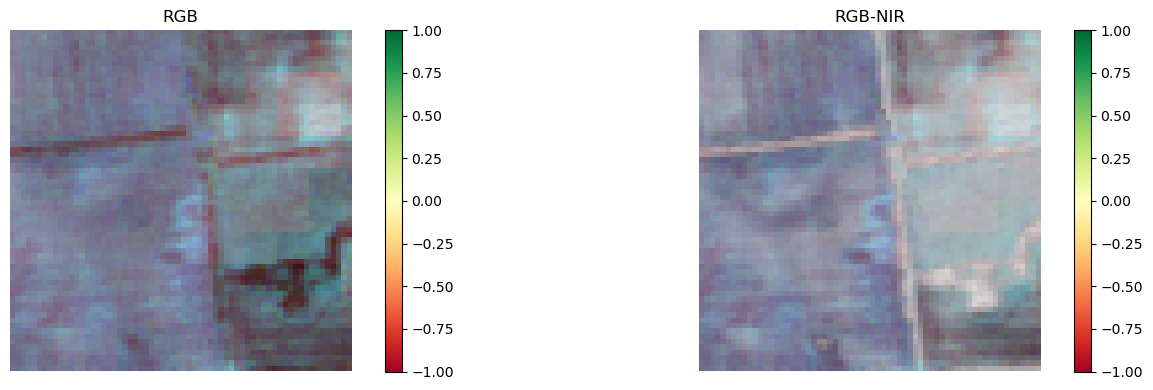

GAN Image


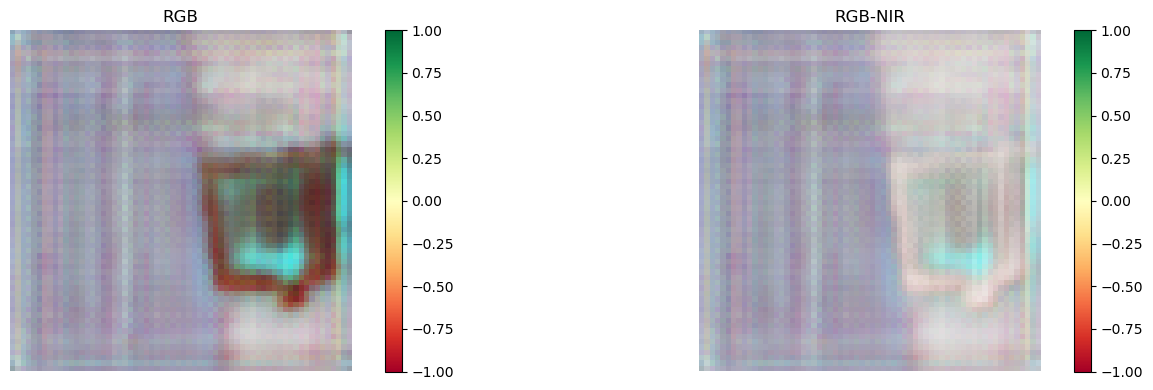

------------------------- Timestamp: 5 -------------------------
Original Image


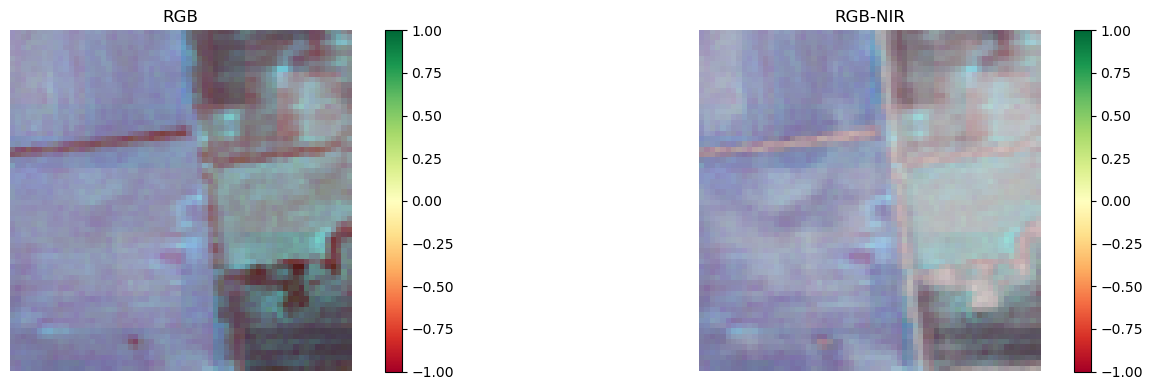

GAN Image


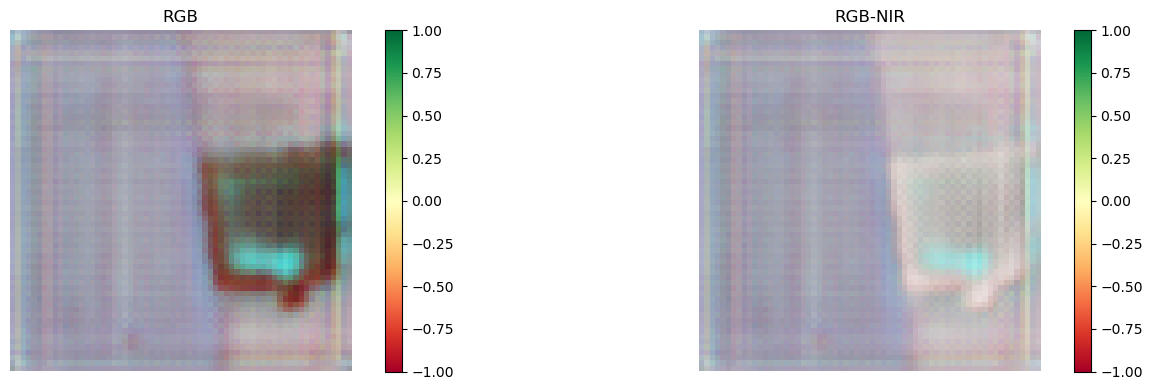

------------------------- Timestamp: 6 -------------------------
Original Image


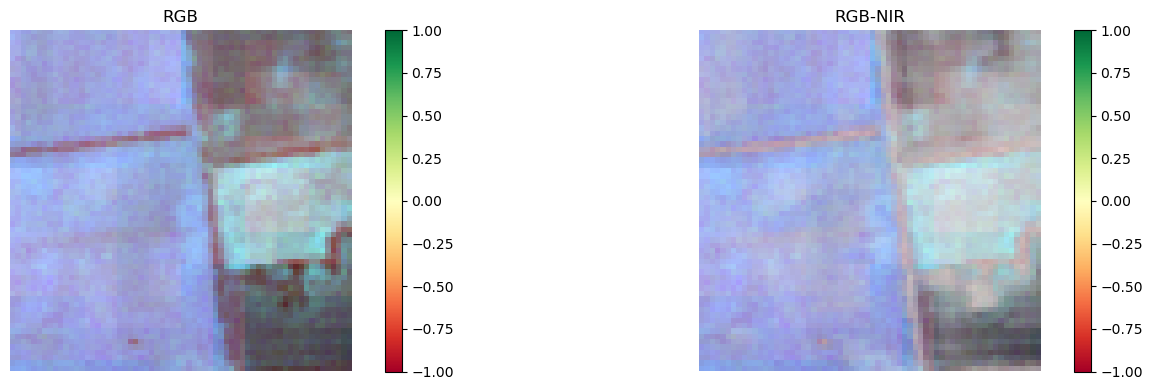

GAN Image


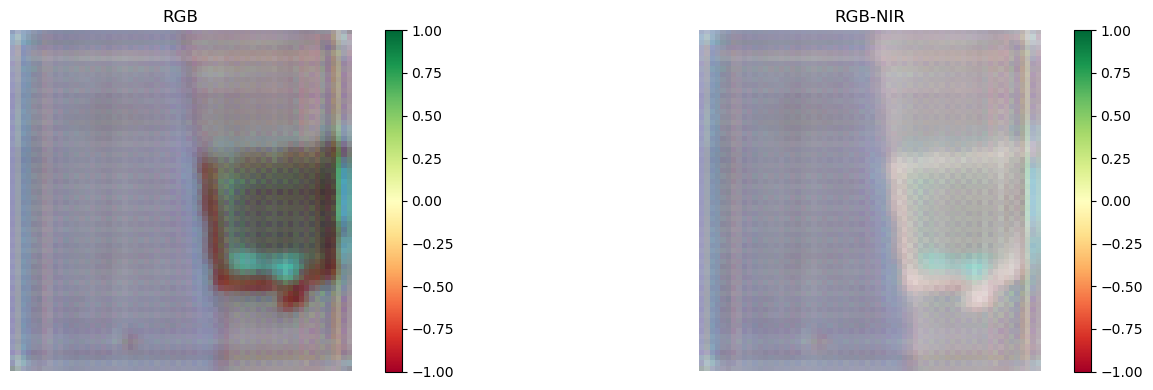

------------------------- Timestamp: 7 -------------------------
Original Image


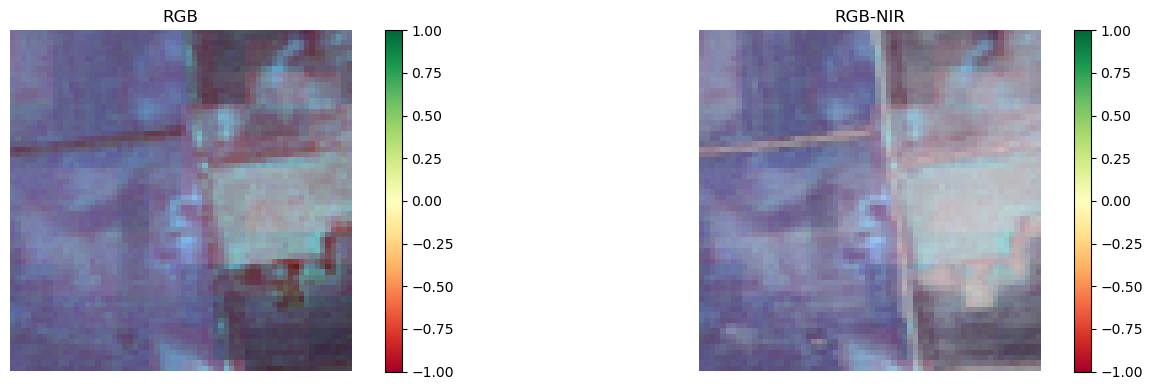

GAN Image


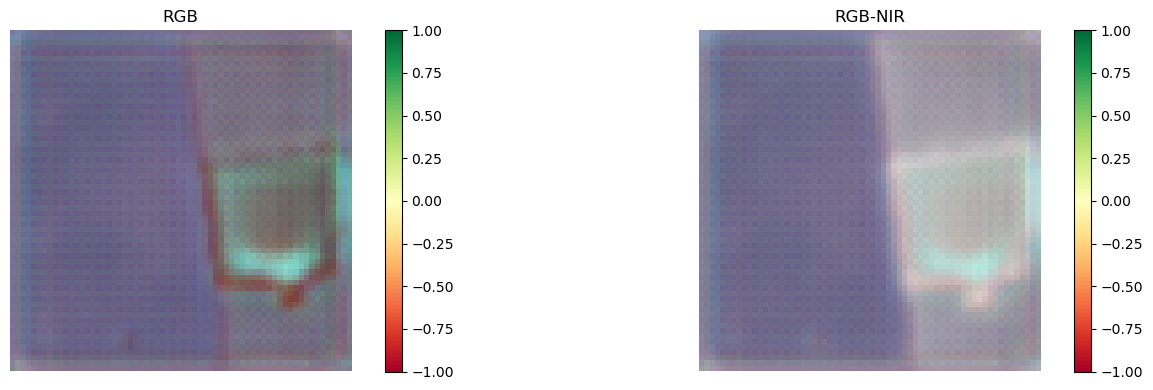

------------------------- Timestamp: 8 -------------------------
Original Image


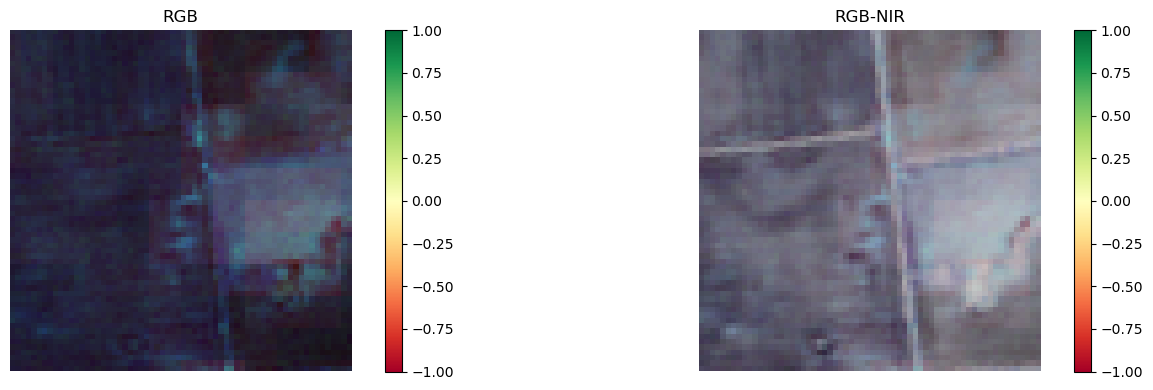

GAN Image


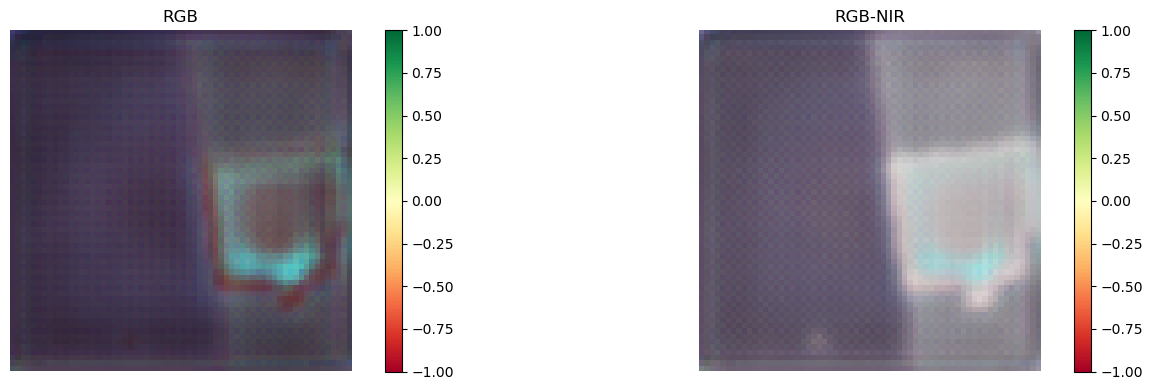

------------------------- Timestamp: 9 -------------------------
Original Image


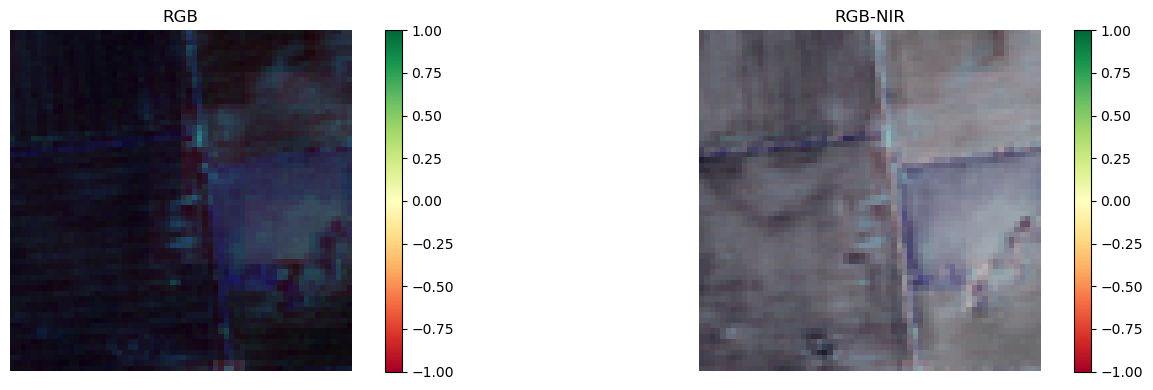

GAN Image


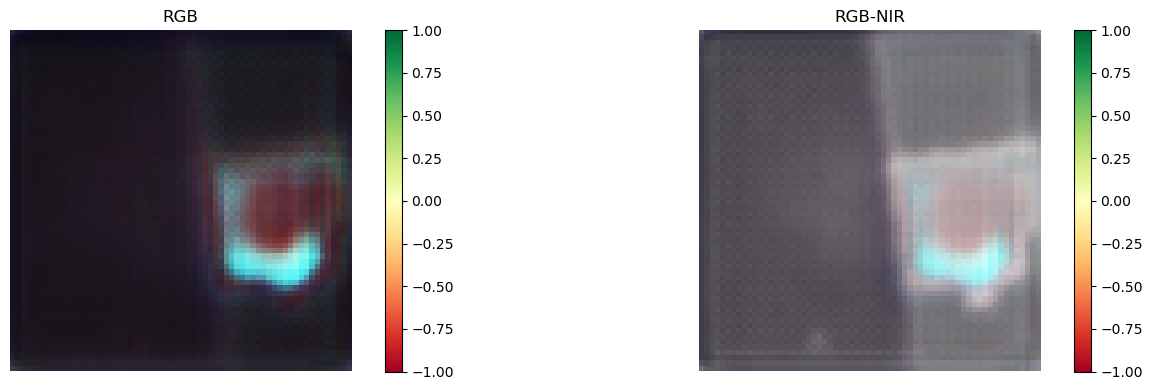

------------------------- Timestamp: 10 -------------------------
Original Image


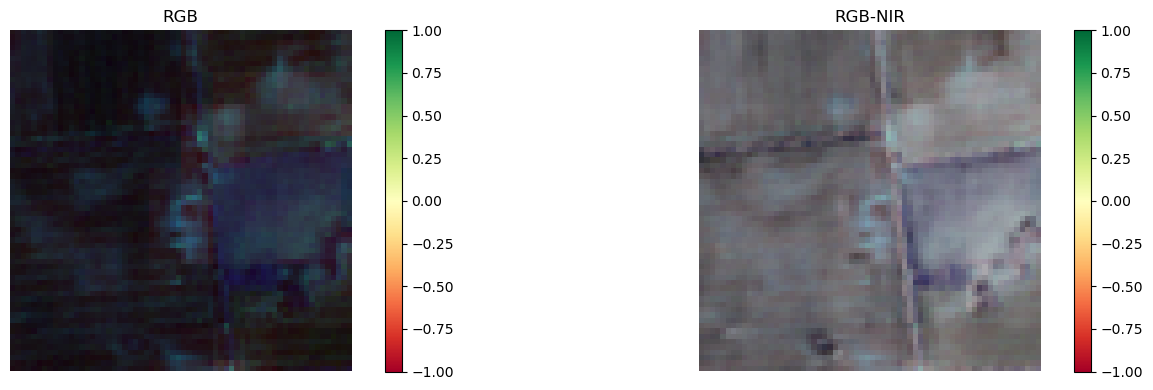

GAN Image


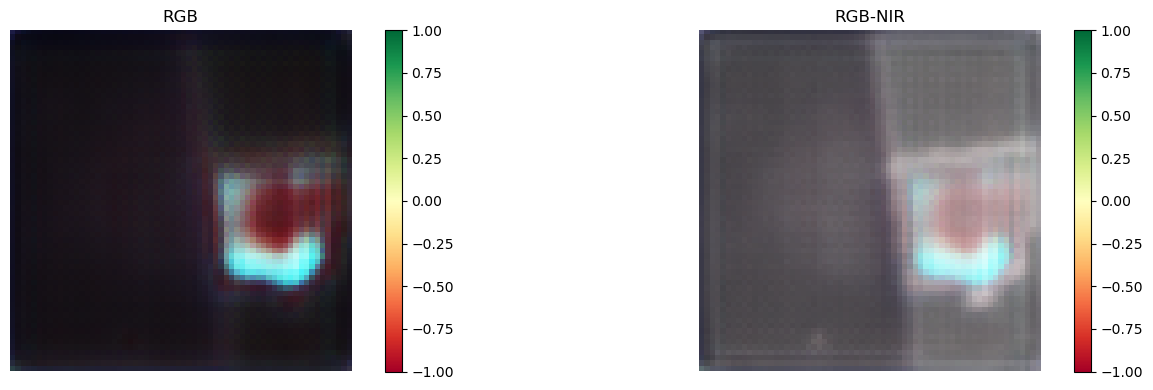

------------------------- Timestamp: 11 -------------------------
Original Image


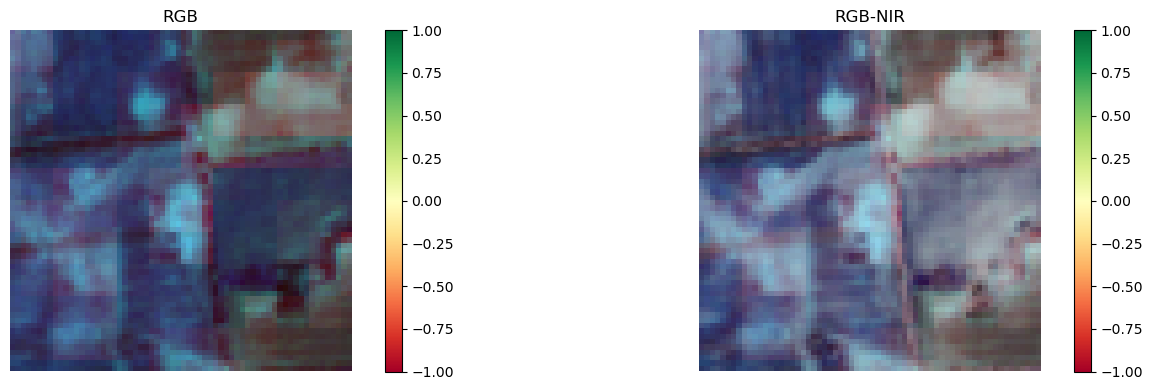

GAN Image


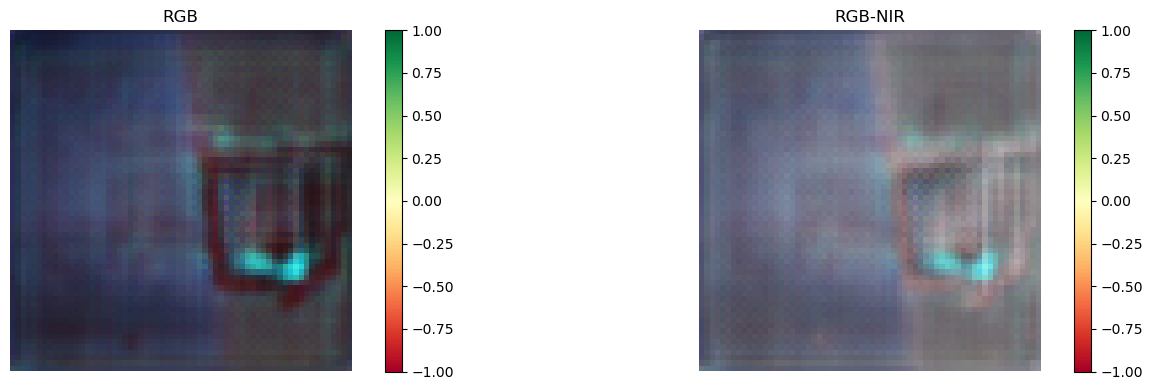

------------------------- Timestamp: 12 -------------------------
Original Image


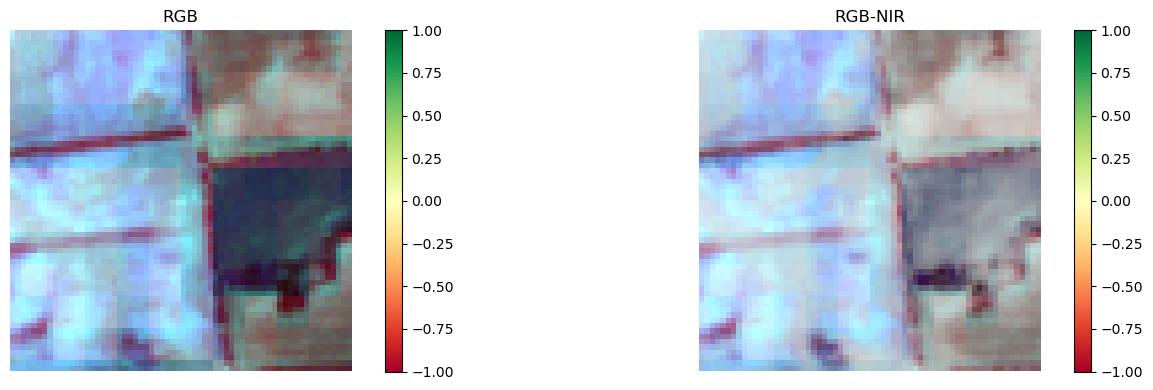

GAN Image


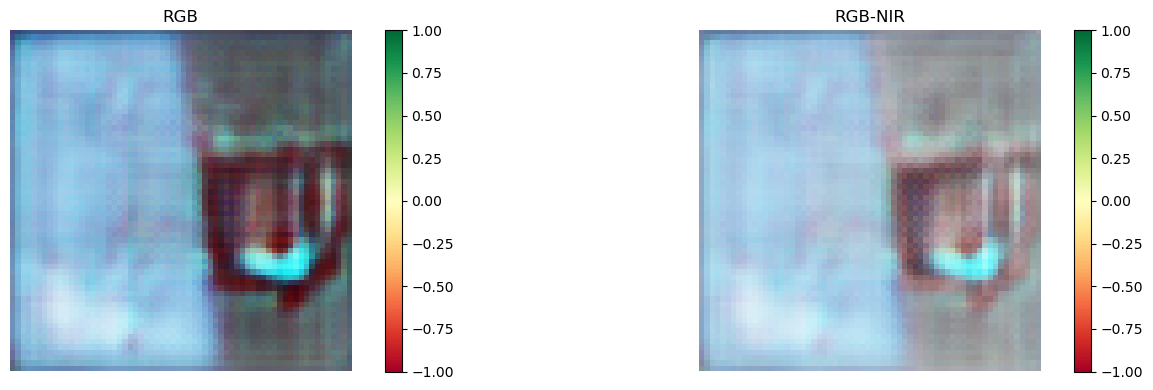

------------------------- Timestamp: 13 -------------------------
Original Image


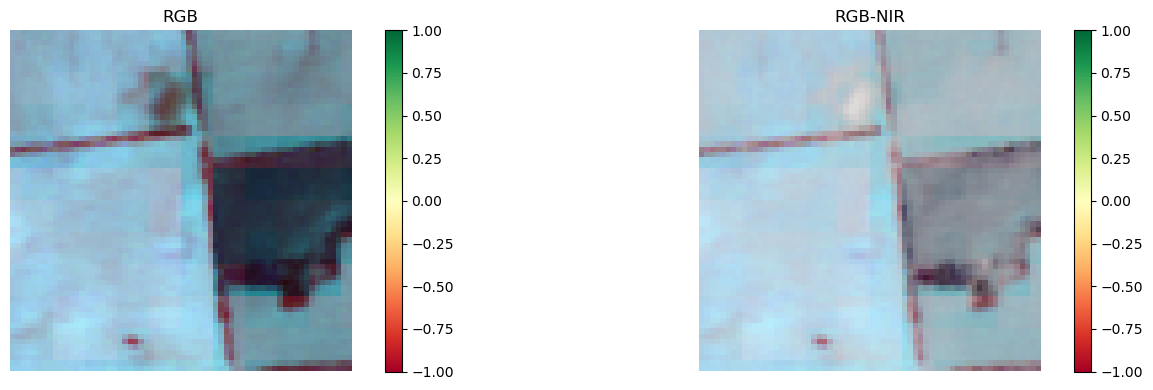

GAN Image


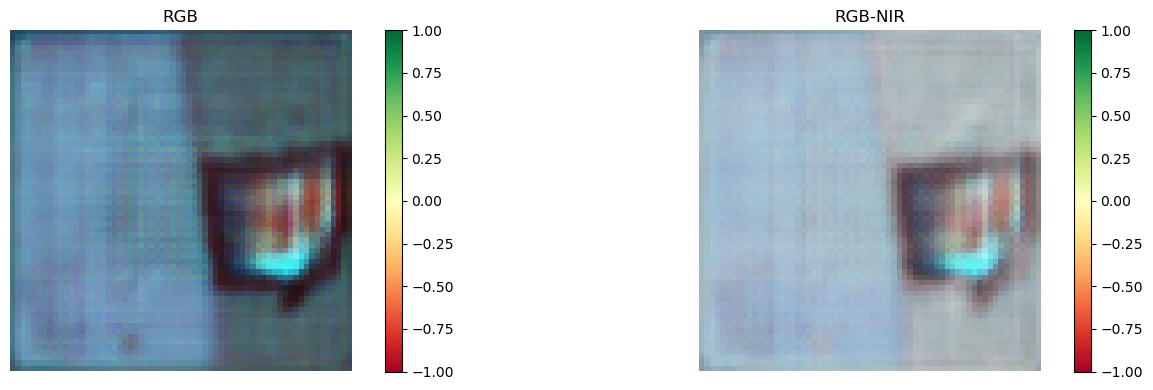

------------------------- Timestamp: 14 -------------------------
Original Image


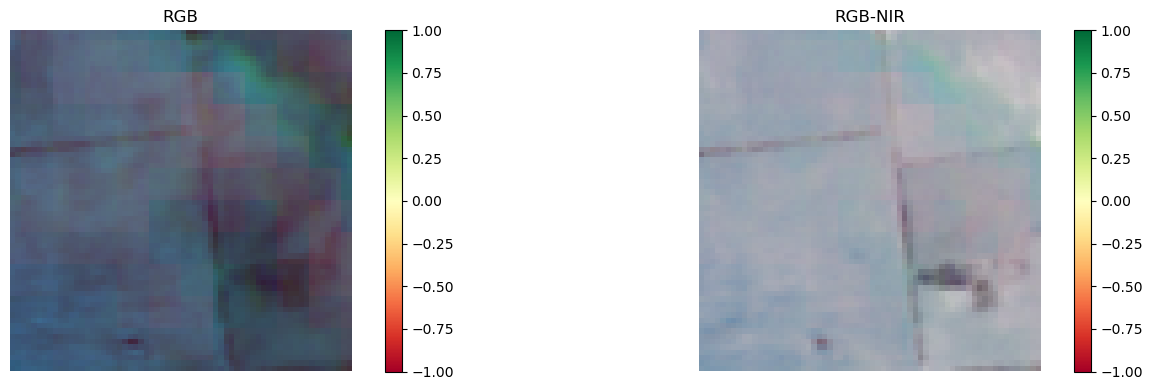

GAN Image


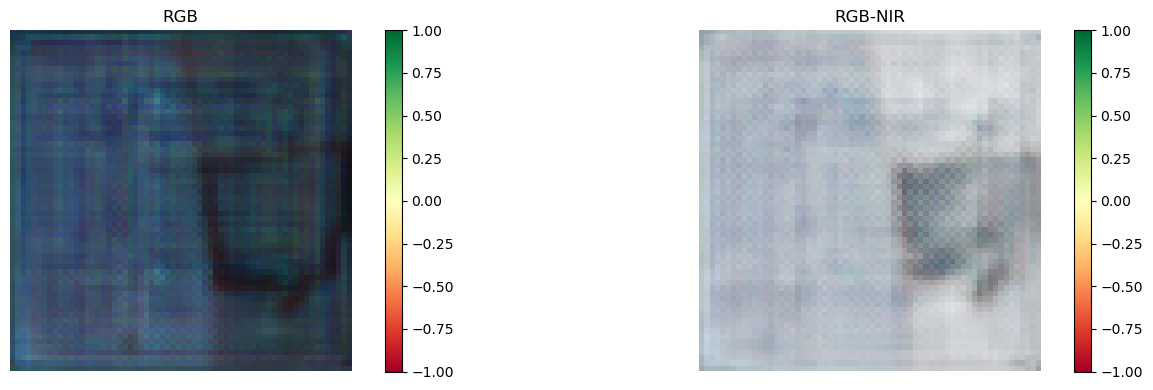

------------------------- Timestamp: 15 -------------------------
Original Image


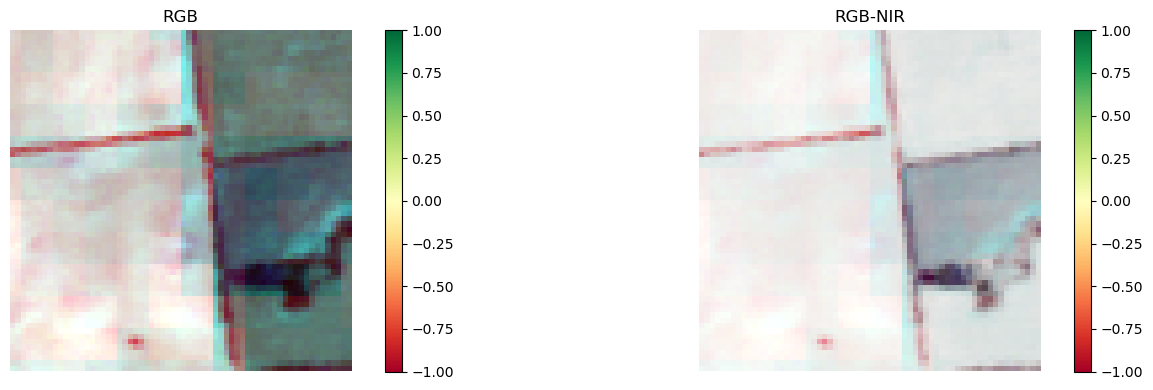

GAN Image


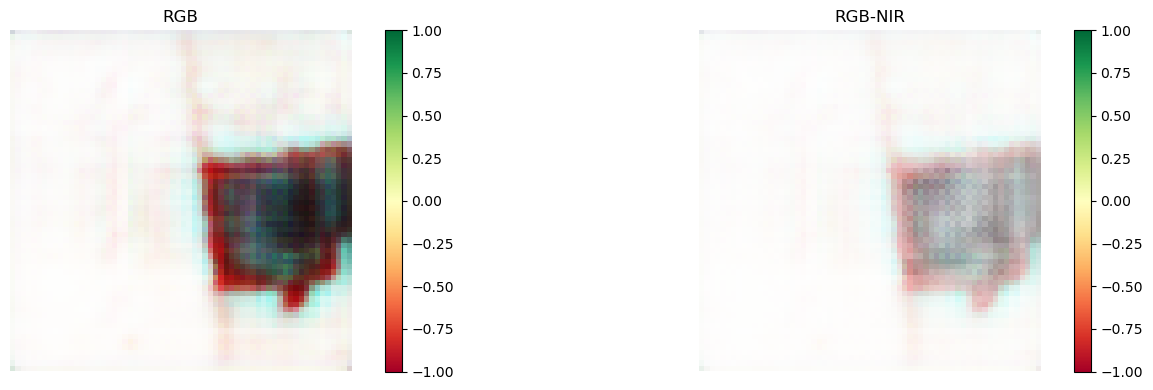

------------------------- Timestamp: 16 -------------------------
Original Image


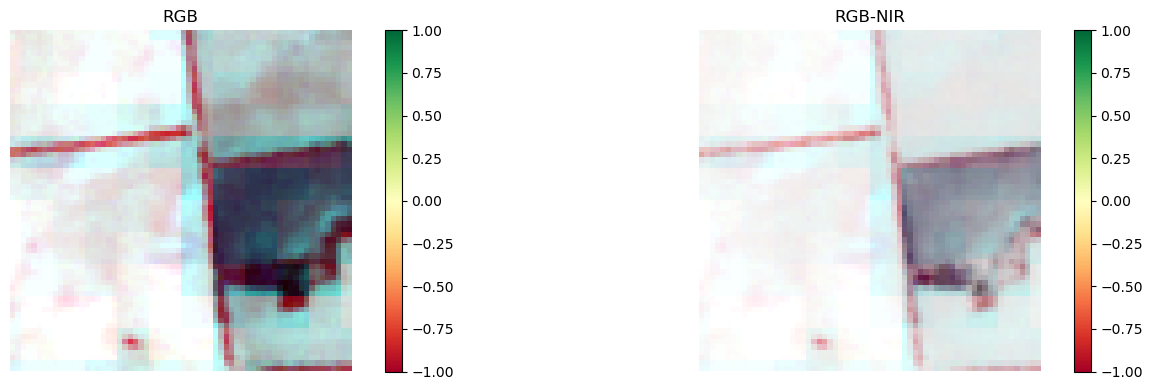

GAN Image


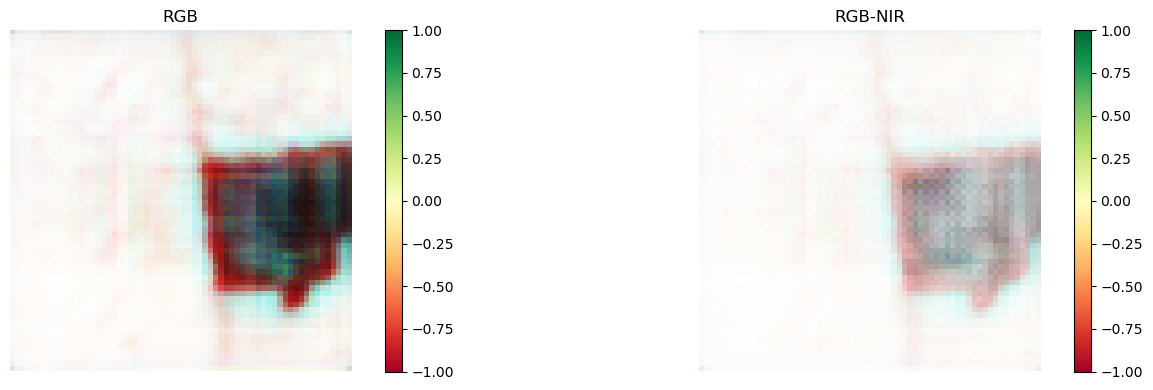

------------------------- Timestamp: 17 -------------------------
Original Image


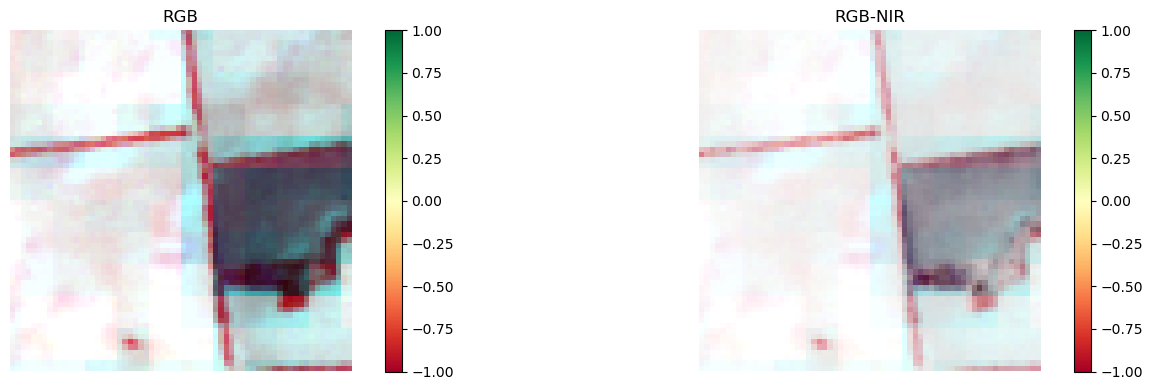

GAN Image


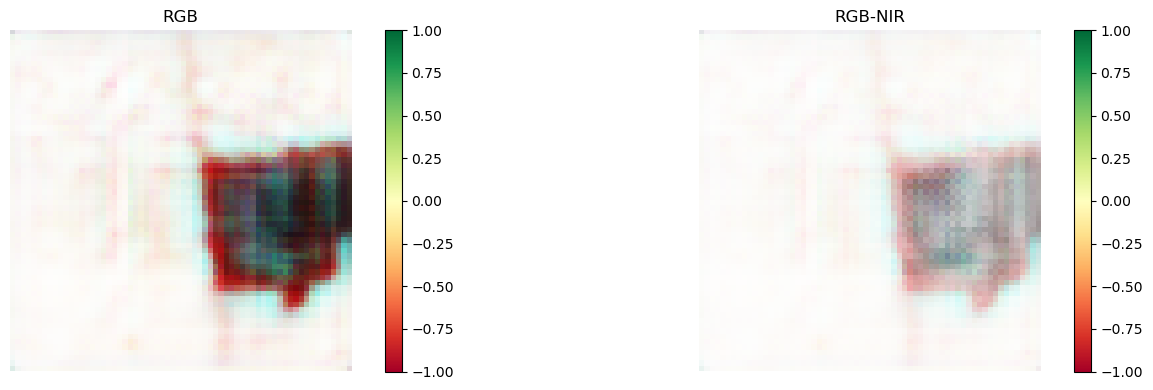

------------------------- Timestamp: 18 -------------------------
Original Image


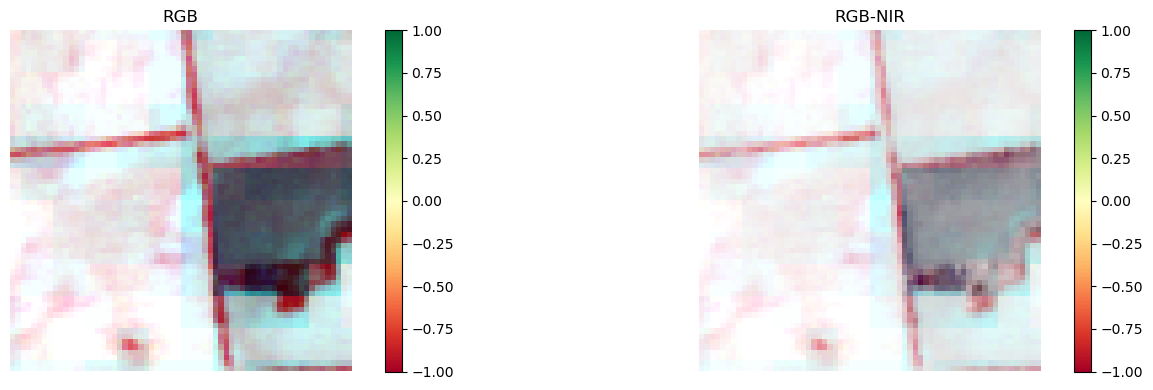

GAN Image


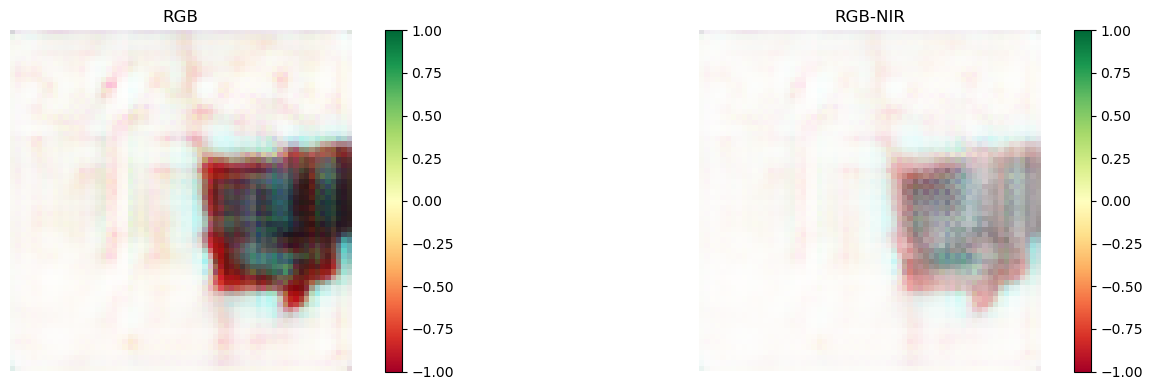

------------------------- Timestamp: 19 -------------------------
Original Image


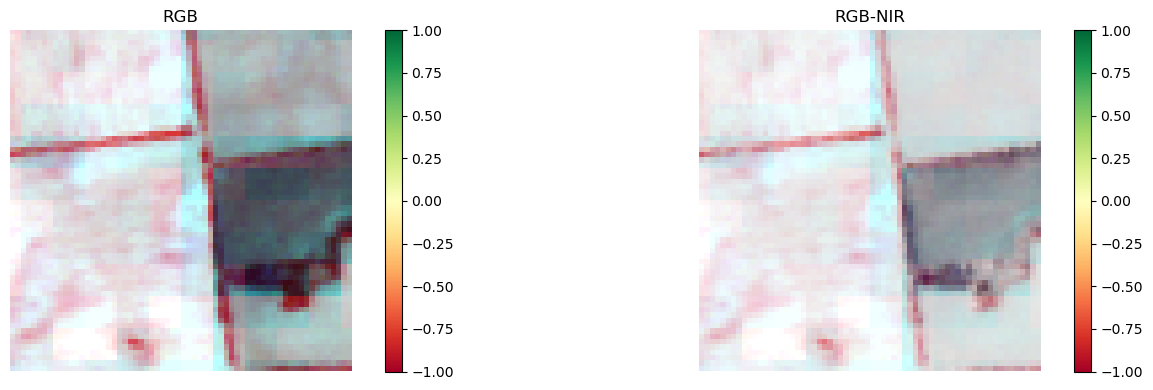

GAN Image


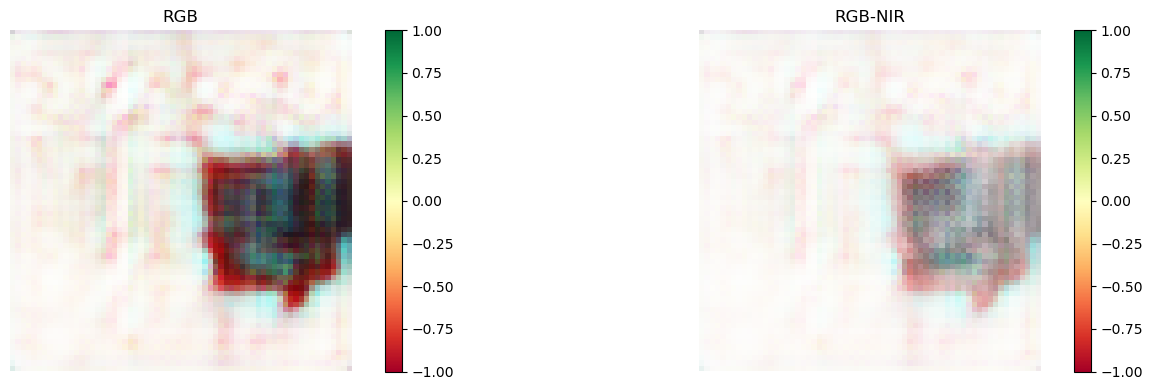

------------------------- Timestamp: 20 -------------------------
Original Image


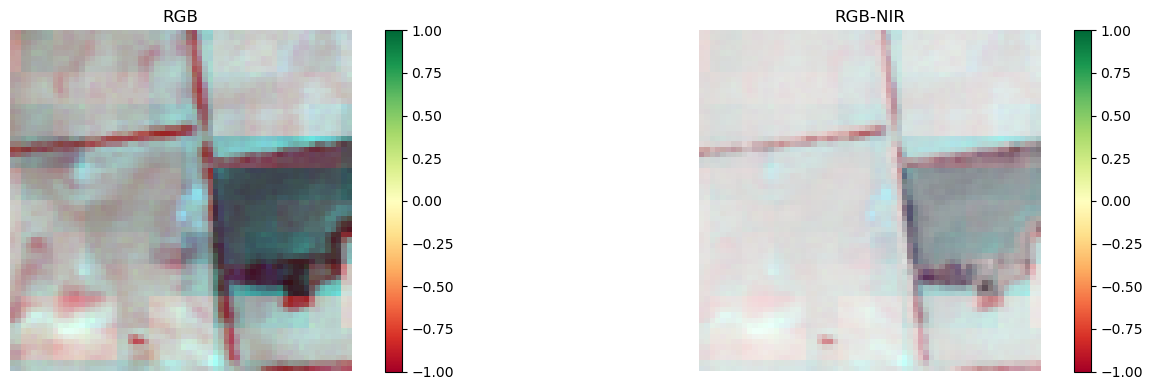

GAN Image


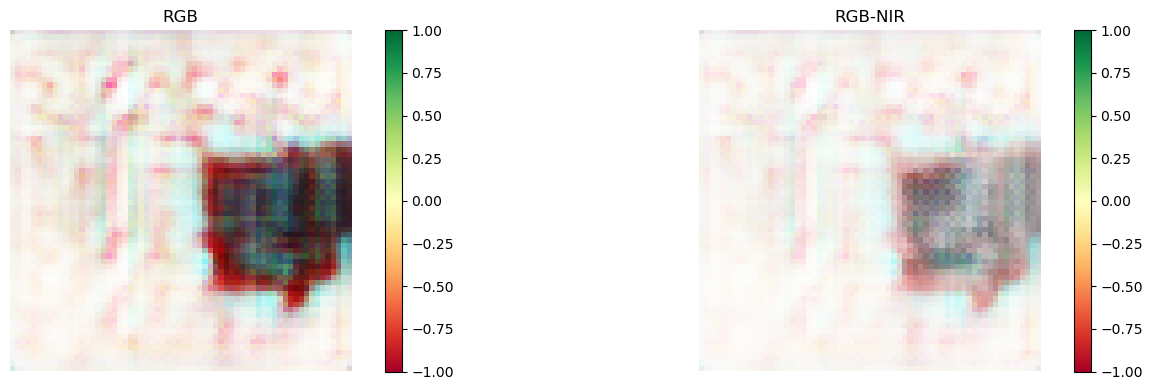

------------------------- Timestamp: 21 -------------------------
Original Image


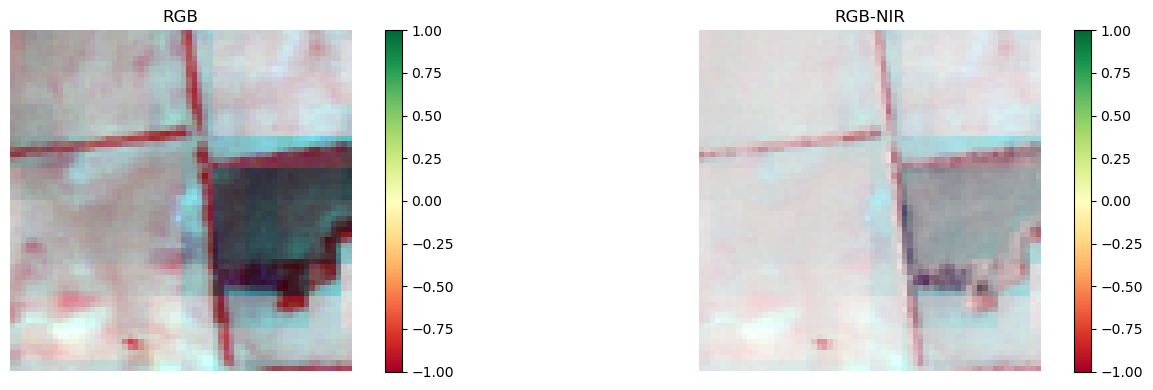

GAN Image


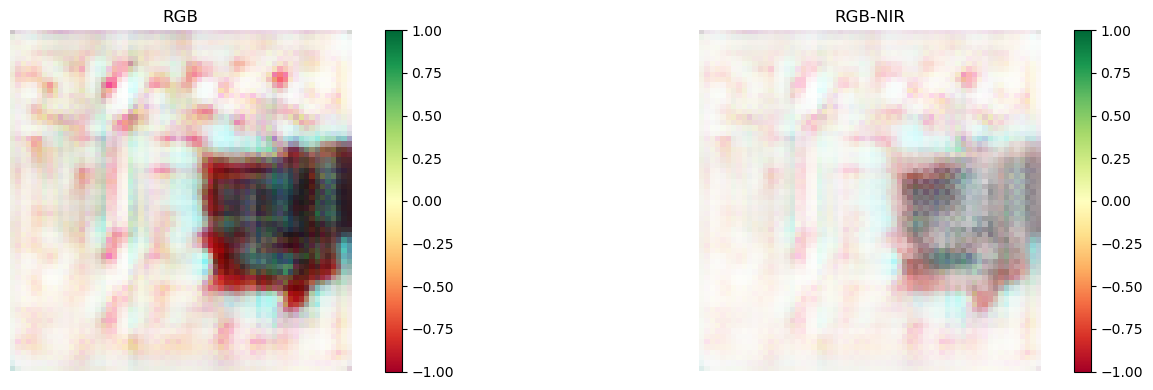

------------------------- Timestamp: 22 -------------------------
Original Image


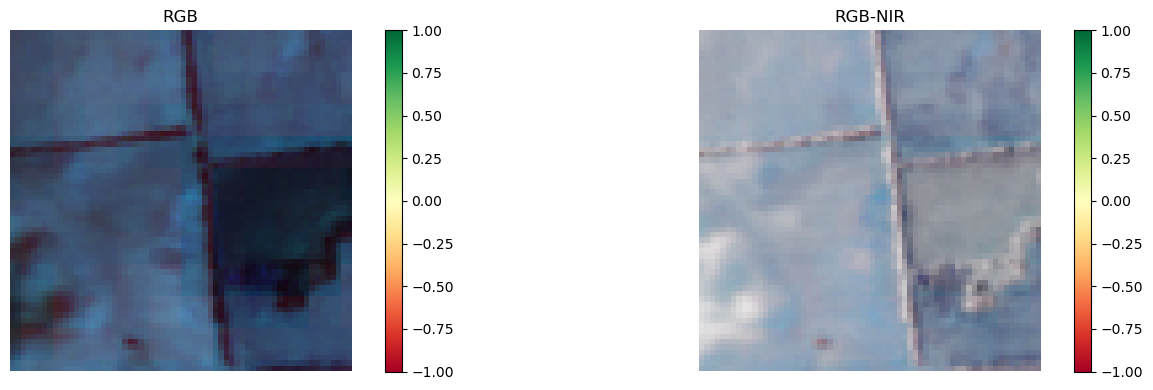

GAN Image


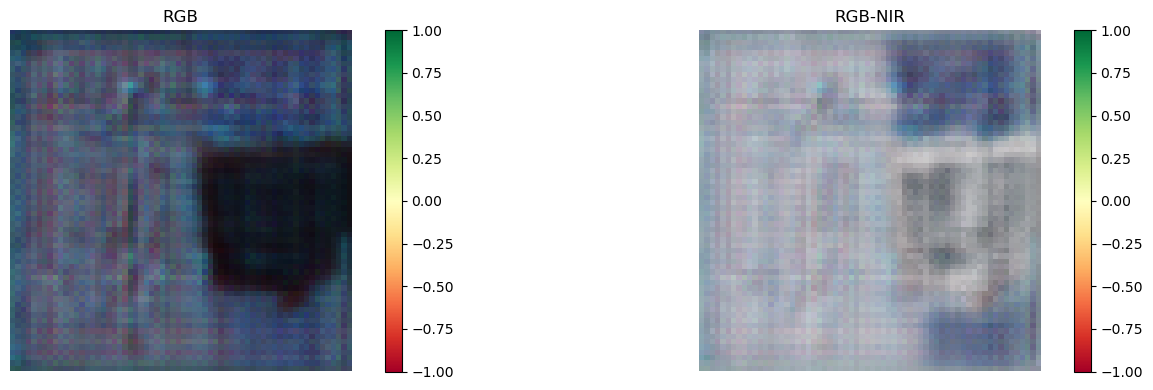

------------------------- Timestamp: 23 -------------------------
Original Image


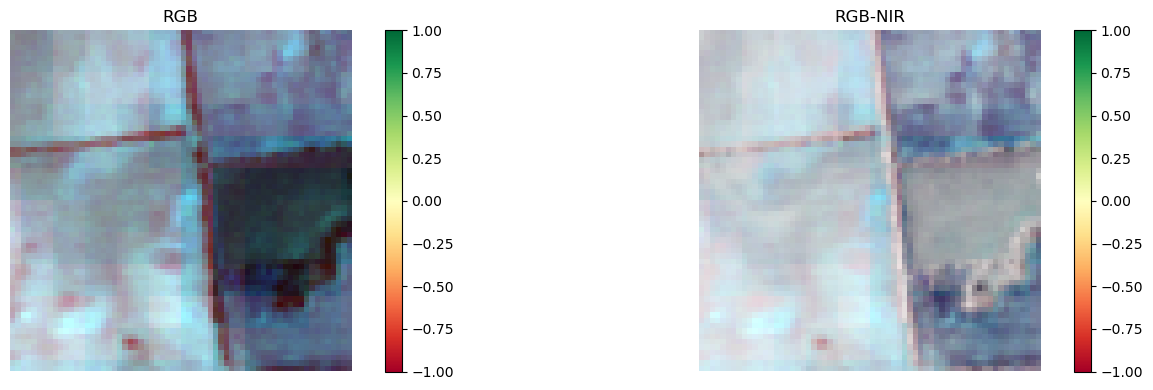

GAN Image


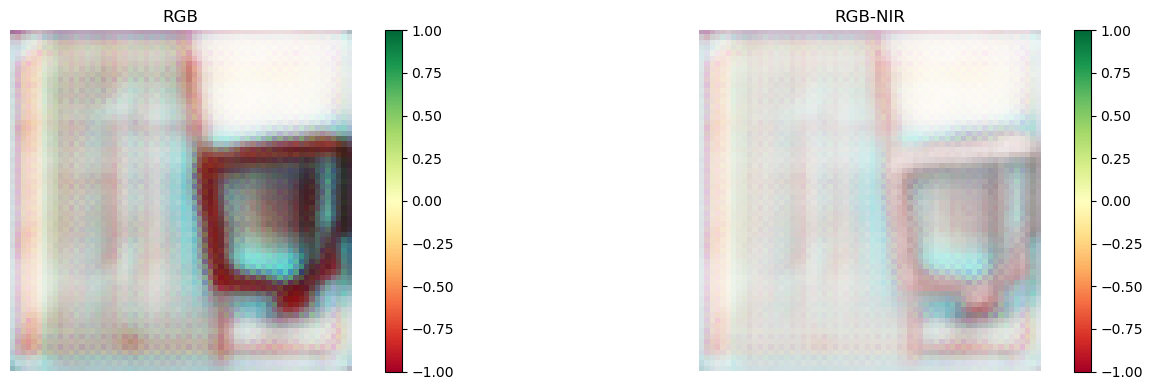

------------------------- Timestamp: 24 -------------------------
Original Image


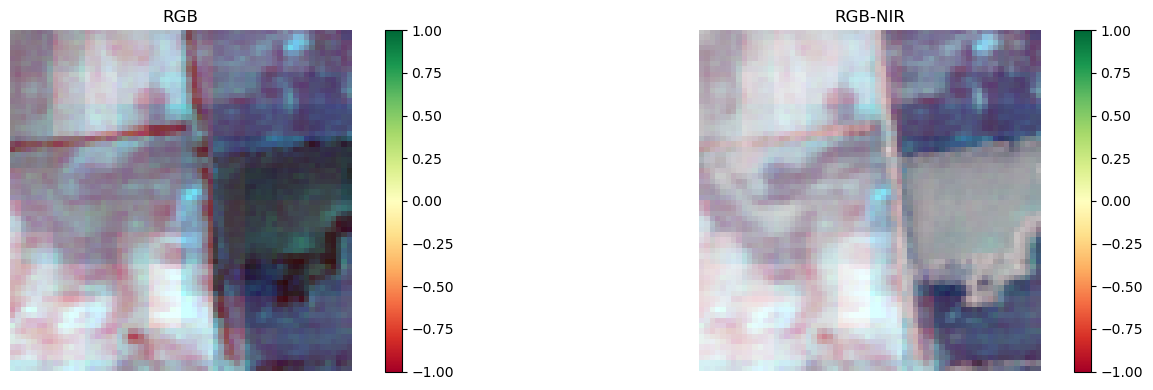

GAN Image


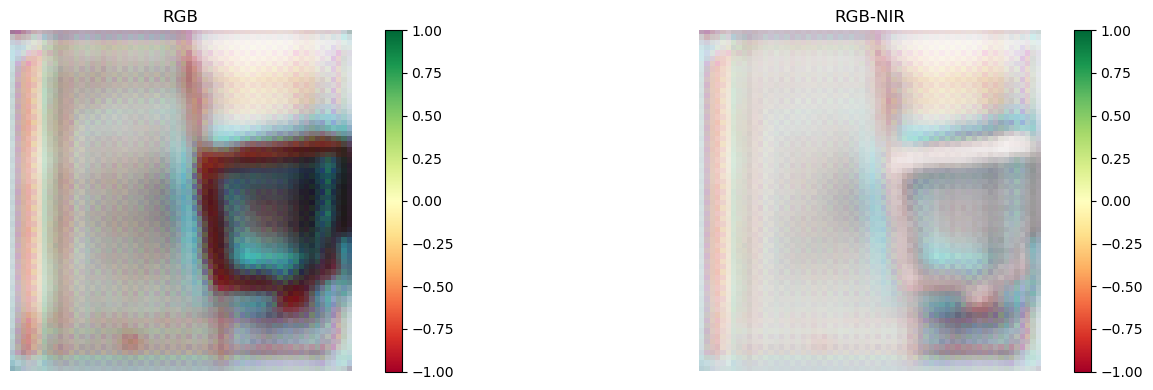

------------------------- Timestamp: 25 -------------------------
Original Image


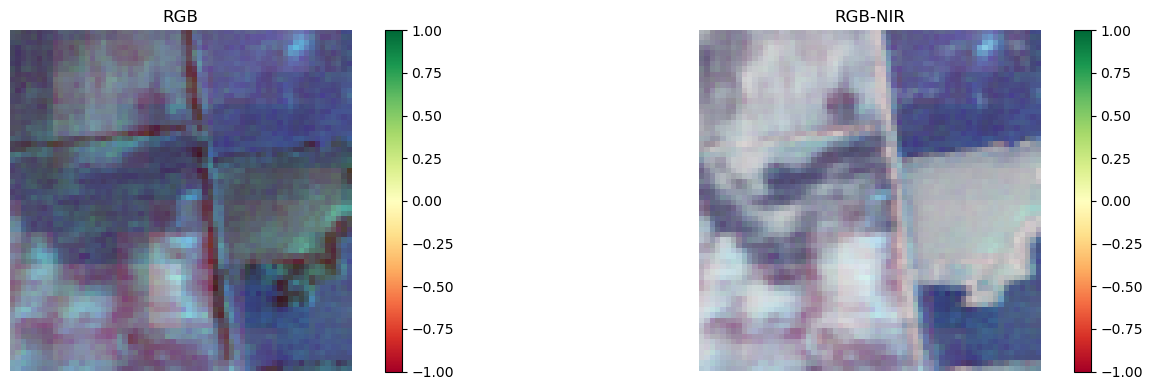

GAN Image


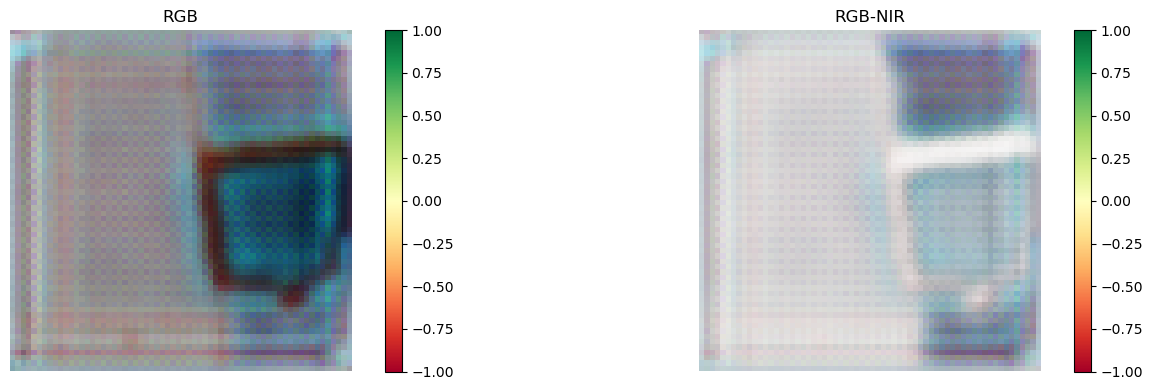

------------------------- Timestamp: 26 -------------------------
Original Image


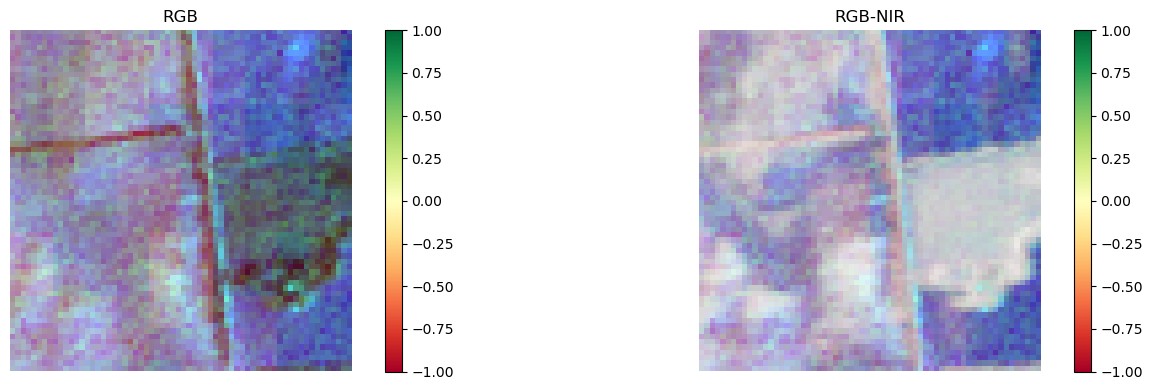

GAN Image


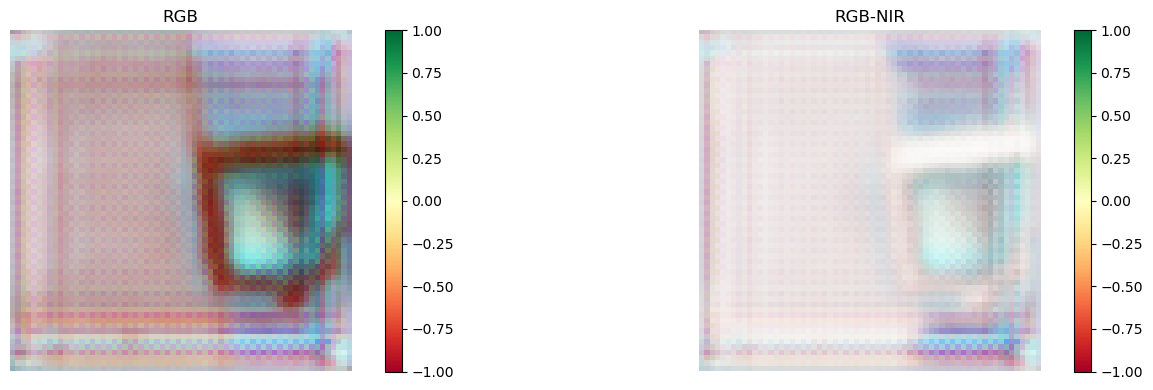

Done. Raw outputs saved in c:\Users\Sai Suhaas\Desktop\Dissertation\Farmland-Classification-using-Remote-Sensing\Notebooks\generated_validation


In [16]:
generator_spatial.eval()
generator_temporal.eval()
G = SequentialGeneratorWrapper(generator_spatial, generator_temporal).to(DEVICE)
G.eval()

# ---- Utility ----
def labels_to_one_hot(label_batch, num_classes, device):
    return F.one_hot(label_batch.long(), num_classes=num_classes).permute(0,3,1,2).float().to(device)

# ---- Core generator with visualization ----
@torch.no_grad()
def generate_and_display(indices,
                         validation_labels,
                         original_data,
                         T=27,
                         doy_list=None,
                         num_classes=10,
                         out_dir="generated_validation",
                         show_every=5):
    """
    indices: int, list[int], 'all'
    validation_labels: numpy array/tensor [N,H,W]
    show_every: display every Nth frame (set 1 to show all)
    """
    # os.makedirs(out_dir, exist_ok=True)

    # Resolve indices
    if indices == 'all':
        idx_list = list(range(len(validation_labels)))
    elif isinstance(indices, int):
        idx_list = [indices]
    elif isinstance(indices, list):
        pass
    else:
        idx_list = list(indices)

    if isinstance(validation_labels, np.ndarray):
        labels_tensor = torch.from_numpy(validation_labels)
    else:
        labels_tensor = validation_labels
    labels_tensor = labels_tensor.long()

    for idx in idx_list:
        label = labels_tensor[idx:idx+1]   # [1,H,W]
        original_data_selected = original_data[idx:idx+1, ...][0]
        # print(original_data_selected.shape)
        one_hot = labels_to_one_hot(label, num_classes=num_classes, device=DEVICE)

        fake_seq = G(one_hot, T=T, doy_list=doy_list)   # [1,T,4,64,64]
        seq = fake_seq[0].cpu().numpy()                 # [T,4,H,W]

        # Convert to [T,H,W,C] for display_images
        seq_thwc = np.transpose(seq, (0,2,3,1))

        # Normalize to [-1,1] for display (if your training already outputs this range, skip)
        seq_thwc = 2.0 * (seq_thwc - seq_thwc.min()) / (seq_thwc.max() - seq_thwc.min() + 1e-8) - 1.0

        # Show a subset of frames
        frames_to_show = list(range(0, T, show_every))
        # for t in frames_to_show:
        #     print(f"Sample {idx}, Frame {t}")
        #     img = seq_thwc[t:t+1]
        #     img = (img+1)/2
        #     display_images(img)  # expects shape [N,H,W,C]

        for t in frames_to_show:
            print('-'*25, f'Timestamp: {t}', '-'*25)
            print("Original Image")
            img = original_data_selected[t:t+1]
            img = (img+1)/2
            display_images(img, show_timestap=False)

            print("GAN Image")
            img = seq_thwc[t:t+1]
            img = (img+1)/2
            display_images(img, show_timestap=False)  

        # Save raw data
        sample_dir = os.path.join(out_dir, f"sample_{idx:05d}")
        # os.makedirs(sample_dir, exist_ok=True)
        # torch.save(fake_seq.cpu(), os.path.join(sample_dir, "sequence.pt"))
        # np.save(os.path.join(sample_dir, "sequence.npy"), seq)

    print(f"Done. Raw outputs saved in {os.path.abspath(out_dir)}")


# Single index:
generate_and_display(23, validation_labels, validation_data.astype(np.float32), T=27, doy_list=doy_list, num_classes=10, show_every=1)

# Multiple indices:
# generate_and_display([0,5,12], validation_labels, T=27, doy_list=doy_list, num_classes=num_classes)

# All validation samples:
# generate_and_display('all', validation_labels, T=27, doy_list=doy_list, num_classes=num_classes, show_every=10)


# Model 1 - 

In [ ]:
def ensure_clean_dir(path: str):
    if os.path.exists(path): shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

@torch.no_grad()
def generate_fake_sequences_batch(G_wrapper, label_masks, T_ref, eval_doy_list, num_classes=10):
    """
    label_masks: torch.LongTensor (B,H,W) class ids
    Returns: torch.Tensor (B,T_ref,4,64,64) in [0,1] on CPU
    """
    one_hot = F.one_hot(label_masks, num_classes=num_classes).permute(0,3,1,2).float().to(label_masks.device)
    fake_seq = G_wrapper(one_hot, T_ref, eval_doy_list)  # (B,T,4,64,64), assume float
    fake_seq = fake_seq.detach()
    return fake_seq

# ---------- save matched REAL/FAKE PNGs for a single timestamp ----------
def save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx_eval, out_real, out_fake):
    """
    For timestamp index t_idx_eval:
      - Save REAL frames imgs[:, t_idx_eval] from loader
      - Save FAKE frames fake_seq_all[:, t_idx_eval]
    Returns: number of pairs saved (min of the two counts)
    """
    ensure_clean_dir(out_real)
    ensure_clean_dir(out_fake)

    # --- REAL ---
    saved_real = 0
    for batch in loader:
        imgs = batch[0]                    # expect (B,T,4,64,64)
        imgs_t = imgs[:, t_idx_eval, ...].float()  # (B,4,64,64)
        imgs_t = (imgs_t.clamp(-1, 1) + 1) / 2
        for i in range(imgs_t.size(0)):
            save_image(imgs_t[i], os.path.join(out_real, f"{saved_real:06d}.png"))
            saved_real += 1

    # --- FAKE ---
    fake_t = fake_seq_all[:, t_idx_eval, ...]       # torch (N,4,64,64) in [0,1]
    saved_fake = 0
    for i in range(fake_t.size(0)):
        save_image(fake_t[i], os.path.join(out_fake, f"{saved_fake:06d}.png"))
        saved_fake += 1

    # If counts differ, trim the larger dir to the smaller count (keeps FID sane)
    n_pairs = min(saved_real, saved_fake)
    if saved_real != n_pairs:
        for k in range(n_pairs, saved_real):
            p = os.path.join(out_real, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)
    if saved_fake != n_pairs:
        for k in range(n_pairs, saved_fake):
            p = os.path.join(out_fake, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)

    return n_pairs

date_list_model2 = ['2025-09-12', '2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-16']
date_list_model1 = ['2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-17', '2025-09-17', '2025-09-18']
if model_data['id'] == 1:
    date_list= date_list_model1
else:
    date_list= date_list_model2

# Expect validation_data to be (N,T,4,64,64).
# If it's (N,T,64,64,4), transpose once:
if validation_data.ndim == 5 and validation_data.shape[2] != 4:
    if validation_data.shape[-1] == 4:
        validation_data = np.transpose(validation_data, (0, 1, 4, 2, 3)).copy()
    else:
        raise ValueError("validation_data has unexpected shape, expected (N,T,4,H,W).")

N, T_ref = validation_data.shape[0], validation_data.shape[1]

# Your dataset must yield (imgs, labels) where imgs is (B,T,4,64,64) tensor
dataset = ImageLabelDataset(validation_data, validation_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=False)  # shuffle=False for reproducible counts

fid_list, kid_mean_list, kid_std_list = [], [], []

for epoch in [1]:
    # ---- checkpoint path: fix quoting + avoid date_list indexing issues ----
    path = f"../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model {str(model_data['id'])}-Epoch {epoch}_{date_list[epoch-1]}.pth"

    # ---- rebuild models & load ----
    generator_temporal  = TemporalNoiseGenerator().to(DEVICE)
    discriminator_temporal = TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
    generator_spatial   = UNetTransformerGenerator(depth=model_data['depth']).to(DEVICE)
    discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

    g_params      = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
    g_optimizer   = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
    d_optimizer   = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
    d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

    _ = load_models(generator_spatial,
                    generator_temporal,
                    discriminator_spatial,
                    discriminator_temporal,
                    g_optimizer,
                    d_optimizer,
                    d_optimizer_t,
                    path)

    G = SequentialGeneratorWrapper(generator_spatial, generator_temporal).to(DEVICE)
    G.eval()

    # ---- generate FAKE sequences for all validation samples (batched) ----
    fake_chunks = []
    print(len(loader))
    for imgs, labels in loader:
        print(len(fake_chunks))
        labels = labels.long().to(DEVICE)                  # (B,H,W) label ids
        # Use your training DOY list (length T_ref)
        fake_seq_batch = generate_fake_sequences_batch(G, labels, T_ref, doy_list, num_classes=10)  # torch CPU
        fake_chunks.append(fake_seq_batch)
    fake_seq_all = torch.cat(fake_chunks, dim=0)           # (N,T,4,64,64) torch CPU in [0,1]

    # if epoch==1:
    #     print("Generated images")

    # ---- per-timestamp metrics -> weighted aggregate ----
    per_t_fid, per_t_kid, per_t_kid_std, per_t_counts = [], [], [], []
    for t_idx in range(T_ref):
        # if epoch==1:
        #     print(f"KID and FID calculation starting for timestamp: {t_idx}")
        real_dir = "./fid_real"
        fake_dir = "./fid_fake"

        n_pairs = save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx, real_dir, fake_dir)
        if n_pairs < 5:
            # too small to be stable. skip this t
            ensure_clean_dir(real_dir)
            ensure_clean_dir(fake_dir)
            continue

        metrics = calculate_metrics(
            input1=real_dir,
            input2=fake_dir,
            fid=True,
            kid=True,
            verbose=False,
            cuda=True
        )

        per_t_fid.append(metrics['frechet_inception_distance'])
        per_t_kid.append(metrics['kernel_inception_distance_mean'])
        per_t_kid_std.append(metrics['kernel_inception_distance_std'])
        per_t_counts.append(n_pairs)

        print(f"[Epoch: {epoch} | t={t_idx}] FID={per_t_fid[-1]:.3f}  KID={per_t_kid[-1]:.6f}  (n={n_pairs})")

    if len(per_t_counts) == 0:
        print(f"[Epoch {epoch}] No valid timestamp pairs.")
        fid_list.append(np.nan)
        kid_mean_list.append(np.nan)
        kid_std_list.append(np.nan)
        continue

    w = np.asarray(per_t_counts, dtype=np.float64)
    w /= w.sum()

    fid_w     = float(np.sum(w * np.asarray(per_t_fid)))
    kid_w     = float(np.sum(w * np.asarray(per_t_kid)))
    kid_std_w = float(np.sum(w * np.asarray(per_t_kid_std)))  # rough combine

    fid_list.append(fid_w)
    kid_mean_list.append(kid_w)
    kid_std_list.append(kid_std_w)
    print(f"[Epoch {epoch}]  FID(weighted)={fid_w:.3f}  KID(weighted)={kid_w:.6f}")


Models loaded from ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 1-Epoch 1_2025-09-12.pth (Epoch 1)
111
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
Generated images
KID and FID calculation starting for timestamp: 0


c:\Users\Sai Suhaas\.conda\envs\myenv\lib\site-packages\torch_fidelity\datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)


[Epoch: 1 | t=0] FID=184.121  KID=0.182195  (n=1762)
KID and FID calculation starting for timestamp: 1
[Epoch: 1 | t=1] FID=195.104  KID=0.190336  (n=1762)
KID and FID calculation starting for timestamp: 2
[Epoch: 1 | t=2] FID=211.908  KID=0.207073  (n=1762)
KID and FID calculation starting for timestamp: 3
[Epoch: 1 | t=3] FID=215.835  KID=0.200293  (n=1762)
KID and FID calculation starting for timestamp: 4
[Epoch: 1 | t=4] FID=238.731  KID=0.225995  (n=1762)
KID and FID calculation starting for timestamp: 5
[Epoch: 1 | t=5] FID=254.232  KID=0.249715  (n=1762)
KID and FID calculation starting for timestamp: 6
[Epoch: 1 | t=6] FID=256.545  KID=0.252311  (n=1762)
KID and FID calculation starting for timestamp: 7
[Epoch: 1 | t=7] FID=265.790  KID=0.270542  (n=1762)
KID and FID calculation starting for timestamp: 8
[Epoch: 1 | t=8] FID=230.934  KID=0.219229  (n=1762)
KID and FID calculation starting for timestamp: 9
[Epoch: 1 | t=9] FID=226.256  KID=0.212732  (n=1762)
KID and FID calculat

[Epoch 1]  FID(weighted)=227.149  KID(weighted)=0.205797

[Epoch: 5 | t=0] FID=282.012  KID=0.338153  (n=1762)
[Epoch: 5 | t=1] FID=217.777  KID=0.184232  (n=1762)
[Epoch: 5 | t=2] FID=326.821  KID=0.363000  (n=1762)
[Epoch: 5 | t=3] FID=332.236  KID=0.325647  (n=1762)
[Epoch: 5 | t=4] FID=249.528  KID=0.193757  (n=1762)
[Epoch: 5 | t=5] FID=228.177  KID=0.203611  (n=1762)
[Epoch: 5 | t=6] FID=218.701  KID=0.203163  (n=1762)
[Epoch: 5 | t=7] FID=217.496  KID=0.193137  (n=1762)
[Epoch: 5 | t=8] FID=217.821  KID=0.171220  (n=1762)
[Epoch: 5 | t=9] FID=217.459  KID=0.168925  (n=1762)
[Epoch: 5 | t=10] FID=213.621  KID=0.165834  (n=1762)
[Epoch: 5 | t=11] FID=227.438  KID=0.194657  (n=1762)
[Epoch: 5 | t=12] FID=241.185  KID=0.212865  (n=1762)
[Epoch: 5 | t=13] FID=281.826  KID=0.264603  (n=1762)
[Epoch: 5 | t=14] FID=260.726  KID=0.243856  (n=1762)
[Epoch: 5 | t=15] FID=232.854  KID=0.183260  (n=1762)
[Epoch: 5 | t=16] FID=210.509  KID=0.157710  (n=1762)
[Epoch: 5 | t=17] FID=208.853  KID=0.158730  (n=1762)
[Epoch: 5 | t=18] FID=208.819  KID=0.161199  (n=1762)
[Epoch: 5 | t=19] FID=210.582  KID=0.164999  (n=1762)
[Epoch: 5 | t=20] FID=208.336  KID=0.161392  (n=1762)
[Epoch: 5 | t=21] FID=266.202  KID=0.225367  (n=1762)
[Epoch: 5 | t=22] FID=260.381  KID=0.231570  (n=1762)
[Epoch: 5 | t=23] FID=266.639  KID=0.230249  (n=1762)
[Epoch: 5 | t=24] FID=259.232  KID=0.248216  (n=1762)
[Epoch: 5 | t=25] FID=293.013  KID=0.315250  (n=1762)
[Epoch: 5 | t=26] FID=313.931  KID=0.350003  (n=1762)
[Epoch 5]  FID(weighted)=247.118  KID(weighted)=0.222763

[Epoch: 10 | t=0] FID=296.581  KID=0.382852  (n=1762)
[Epoch: 10 | t=1] FID=206.200  KID=0.160610  (n=1762)
[Epoch: 10 | t=2] FID=282.601  KID=0.252723  (n=1762)
[Epoch: 10 | t=3] FID=393.220  KID=0.477950  (n=1762)
[Epoch: 10 | t=4] FID=223.418  KID=0.169409  (n=1762)
[Epoch: 10 | t=5] FID=221.059  KID=0.186431  (n=1762)
[Epoch: 10 | t=6] FID=212.791  KID=0.185669  (n=1762)
[Epoch: 10 | t=7] FID=218.665  KID=0.186442  (n=1762)
[Epoch: 10 | t=8] FID=254.849  KID=0.214899  (n=1762)
[Epoch: 10 | t=9] FID=270.544  KID=0.232227  (n=1762)
[Epoch: 10 | t=10] FID=255.707  KID=0.207990  (n=1762)
[Epoch: 10 | t=11] FID=265.906  KID=0.234844  (n=1762)
[Epoch: 10 | t=12] FID=229.660  KID=0.196751  (n=1762)
[Epoch: 10 | t=13] FID=330.696  KID=0.355986  (n=1762)
[Epoch: 10 | t=14] FID=401.197  KID=0.524504  (n=1762)
[Epoch: 10 | t=15] FID=203.016  KID=0.138594  (n=1762)
[Epoch: 10 | t=16] FID=181.868  KID=0.112248  (n=1762)
[Epoch: 10 | t=17] FID=168.367  KID=0.101518  (n=1762)
[Epoch: 10 | t=18] FID=158.083  KID=0.092366  (n=1762)
[Epoch: 10 | t=19] FID=160.712  KID=0.096317  (n=1762)
[Epoch: 10 | t=20] FID=162.106  KID=0.098025  (n=1762)
[Epoch: 10 | t=21] FID=211.847  KID=0.150395  (n=1762)
[Epoch: 10 | t=22] FID=284.330  KID=0.289516  (n=1762)
[Epoch: 10 | t=23] FID=229.292  KID=0.181035  (n=1762)
[Epoch: 10 | t=24] FID=219.975  KID=0.180948  (n=1762)
[Epoch: 10 | t=25] FID=224.657  KID=0.204695  (n=1762)
[Epoch: 10 | t=26] FID=252.627  KID=0.252942  (n=1762)
[Epoch 10]  FID(weighted)=241.481  KID(weighted)=0.217329

# Model 2 

## e1

In [2]:
model_data = {
    "id": 2,              # Integer value 
    "start_epoch": 1,    # Integer
    "end_epoch": 10,     # Integer
    "depth": 8,           # No of layers,
    "interval": 1,       # Model save frequency in epochs
    "best_model": 10,     # Based on loss curves along with FID and KID scores 
    "date": "2025-09-16", # Format: YYYY-MM-DD # Best model date
}

# model_data = {
#     "id": 1,              # Integer value 
#     "start_epoch": 1,    # Integer
#     "end_epoch": 10,     # Integer
#     "depth": 4,           # No of layers,
#     "interval": 1,       # Model save frequency in epochs
#     "best_model": 10,     # Based on loss curves along with FID and KID scores 
#     "date": "2025-09-18", # Format: YYYY-MM-DD # Best model date
# }

selected_model_path = "../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model "+ str(model_data["id"]) +"-Epoch "+str(model_data["best_model"])+"_"+model_data["date"]+".pth"


In [ ]:
def ensure_clean_dir(path: str):
    if os.path.exists(path): shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

@torch.no_grad()
def generate_fake_sequences_batch(G_wrapper, label_masks, T_ref, eval_doy_list, num_classes=10):
    """
    label_masks: torch.LongTensor (B,H,W) class ids
    Returns: torch.Tensor (B,T_ref,4,64,64) in [0,1] on CPU
    """
    one_hot = F.one_hot(label_masks, num_classes=num_classes).permute(0,3,1,2).float().to(label_masks.device)
    fake_seq = G_wrapper(one_hot, T_ref, eval_doy_list)  # (B,T,4,64,64), assume float
    fake_seq = fake_seq.detach()
    return fake_seq

# ---------- save matched REAL/FAKE PNGs for a single timestamp ----------
def save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx_eval, out_real, out_fake):
    """
    For timestamp index t_idx_eval:
      - Save REAL frames imgs[:, t_idx_eval] from loader
      - Save FAKE frames fake_seq_all[:, t_idx_eval]
    Returns: number of pairs saved (min of the two counts)
    """
    ensure_clean_dir(out_real)
    ensure_clean_dir(out_fake)

    # --- REAL ---
    saved_real = 0
    for batch in loader:
        imgs = batch[0]                    # expect (B,T,4,64,64)
        imgs_t = imgs[:, t_idx_eval, ...].float()  # (B,4,64,64)
        imgs_t = (imgs_t.clamp(-1, 1) + 1) / 2
        for i in range(imgs_t.size(0)):
            save_image(imgs_t[i], os.path.join(out_real, f"{saved_real:06d}.png"))
            saved_real += 1

    # --- FAKE ---
    fake_t = fake_seq_all[:, t_idx_eval, ...]       # torch (N,4,64,64) in [0,1]
    saved_fake = 0
    for i in range(fake_t.size(0)):
        save_image(fake_t[i], os.path.join(out_fake, f"{saved_fake:06d}.png"))
        saved_fake += 1

    # If counts differ, trim the larger dir to the smaller count (keeps FID sane)
    n_pairs = min(saved_real, saved_fake)
    if saved_real != n_pairs:
        for k in range(n_pairs, saved_real):
            p = os.path.join(out_real, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)
    if saved_fake != n_pairs:
        for k in range(n_pairs, saved_fake):
            p = os.path.join(out_fake, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)

    return n_pairs

date_list_model2 = ['2025-09-12', '2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-16']
date_list_model1 = ['2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-17', '2025-09-17', '2025-09-18']
if model_data['id'] == 1:
    date_list= date_list_model1
else:
    date_list= date_list_model2

# Expect validation_data to be (N,T,4,64,64).
# If it's (N,T,64,64,4), transpose once:
if validation_data.ndim == 5 and validation_data.shape[2] != 4:
    if validation_data.shape[-1] == 4:
        validation_data = np.transpose(validation_data, (0, 1, 4, 2, 3)).copy()
    else:
        raise ValueError("validation_data has unexpected shape. expected (N,T,4,H,W).")

N, T_ref = validation_data.shape[0], validation_data.shape[1]

# Your dataset must yield (imgs, labels) where imgs is (B,T,4,64,64) tensor
dataset = ImageLabelDataset(validation_data, validation_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=False)  # shuffle=False for reproducible counts

fid_list, kid_mean_list, kid_std_list = [], [], []

for epoch in [1]:
    # ---- checkpoint path: fix quoting + avoid date_list indexing issues ----
    path = f"../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model {str(model_data['id'])}-Epoch {epoch}_{date_list[epoch-1]}.pth"

    # ---- rebuild models & load ----
    generator_temporal  = TemporalNoiseGenerator().to(DEVICE)
    discriminator_temporal = TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
    generator_spatial   = UNetTransformerGenerator(depth=model_data['depth']).to(DEVICE)
    discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

    g_params      = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
    g_optimizer   = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
    d_optimizer   = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
    d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

    _ = load_models(generator_spatial,
                    generator_temporal,
                    discriminator_spatial,
                    discriminator_temporal,
                    g_optimizer,
                    d_optimizer,
                    d_optimizer_t,
                    path)

    G = SequentialGeneratorWrapper(generator_spatial, generator_temporal).to(DEVICE)
    G.eval()

    # ---- generate FAKE sequences for all validation samples (batched) ----
    fake_chunks = []
    print(len(loader))
    for imgs, labels in loader:
        print(len(fake_chunks))
        labels = labels.long().to(DEVICE)                  # (B,H,W) label ids
        # Use your training DOY list (length T_ref)
        fake_seq_batch = generate_fake_sequences_batch(G, labels, T_ref, doy_list, num_classes=10)  # torch CPU
        fake_chunks.append(fake_seq_batch)
    fake_seq_all = torch.cat(fake_chunks, dim=0)           # (N,T,4,64,64) torch CPU in [0,1]

    # ---- per-timestamp metrics -> weighted aggregate ----
    per_t_fid, per_t_kid, per_t_kid_std, per_t_counts = [], [], [], []
    for t_idx in range(T_ref):
        real_dir = "./fid_real"
        fake_dir = "./fid_fake"

        n_pairs = save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx, real_dir, fake_dir)
        if n_pairs < 5:
            # too small to be stable. skip this t
            ensure_clean_dir(real_dir)
            ensure_clean_dir(fake_dir)
            continue

        metrics = calculate_metrics(
            input1=real_dir,
            input2=fake_dir,
            fid=True,
            kid=True,
            verbose=False,
            cuda=True
        )

        per_t_fid.append(metrics['frechet_inception_distance'])
        per_t_kid.append(metrics['kernel_inception_distance_mean'])
        per_t_kid_std.append(metrics['kernel_inception_distance_std'])
        per_t_counts.append(n_pairs)

        print(f"[Epoch: {epoch} | t={t_idx}] FID={per_t_fid[-1]:.3f}  KID={per_t_kid[-1]:.6f}  (n={n_pairs})")

    if len(per_t_counts) == 0:
        print(f"[Epoch {epoch}] No valid timestamp pairs.")
        fid_list.append(np.nan)
        kid_mean_list.append(np.nan)
        kid_std_list.append(np.nan)
        continue

    w = np.asarray(per_t_counts, dtype=np.float64)
    w /= w.sum()

    fid_w     = float(np.sum(w * np.asarray(per_t_fid)))
    kid_w     = float(np.sum(w * np.asarray(per_t_kid)))
    kid_std_w = float(np.sum(w * np.asarray(per_t_kid_std)))  # rough combine

    fid_list.append(fid_w)
    kid_mean_list.append(kid_w)
    kid_std_list.append(kid_std_w)
    print(f"[Epoch {epoch}]  FID(weighted)={fid_w:.3f}  KID(weighted)={kid_w:.6f}")


Models loaded from ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 2-Epoch 1_2025-09-12.pth (Epoch 1)
111
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
[Epoch: 1 | t=0] FID=150.053  KID=0.114015  (n=1762)
[Epoch: 1 | t=1] FID=183.350  KID=0.157364  (n=1762)
[Epoch: 1 | t=2] FID=209.282  KID=0.192062  (n=1762)
[Epoch: 1 | t=3] FID=222.183  KID=0.204064  (n=1762)
[Epoch: 1 | t=4] FID=257.749  KID=0.246886  (n=1762)
[Epoch: 1 | t=5] FID=273.630  KID=0.271798  (n=1762)
[Epoch: 1 | t=6] FID=274.151  KID=0.273225  (n=1762)
[Epoch: 1 | t=7] FID=279.583  KID=0.283719  (n=1762)
[Epoch: 1 | t=8] FID=241.422  KID=0.224611  (n=1762)
[Epoch: 1 | t=9] FID=231.613  KID=0.208793  (n=1762)
[Epoc

## Model 2 - e5

In [ ]:
def ensure_clean_dir(path: str):
    if os.path.exists(path): shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

@torch.no_grad()
def generate_fake_sequences_batch(G_wrapper, label_masks, T_ref, eval_doy_list, num_classes=10):
    """
    label_masks: torch.LongTensor (B,H,W) class ids
    Returns: torch.Tensor (B,T_ref,4,64,64) in [0,1] on CPU
    """
    one_hot = F.one_hot(label_masks, num_classes=num_classes).permute(0,3,1,2).float().to(label_masks.device)
    fake_seq = G_wrapper(one_hot, T_ref, eval_doy_list)  # (B,T,4,64,64), assume float
    fake_seq = fake_seq.detach()
    return fake_seq

# ---------- save matched REAL/FAKE PNGs for a single timestamp ----------
def save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx_eval, out_real, out_fake):
    """
    For timestamp index t_idx_eval:
      - Save REAL frames imgs[:, t_idx_eval] from loader
      - Save FAKE frames fake_seq_all[:, t_idx_eval]
    Returns: number of pairs saved (min of the two counts)
    """
    ensure_clean_dir(out_real)
    ensure_clean_dir(out_fake)

    # --- REAL ---
    saved_real = 0
    for batch in loader:
        imgs = batch[0]                    # expect (B,T,4,64,64)
        imgs_t = imgs[:, t_idx_eval, ...].float()  # (B,4,64,64)
        imgs_t = (imgs_t.clamp(-1, 1) + 1) / 2
        for i in range(imgs_t.size(0)):
            save_image(imgs_t[i], os.path.join(out_real, f"{saved_real:06d}.png"))
            saved_real += 1

    # --- FAKE ---
    fake_t = fake_seq_all[:, t_idx_eval, ...]       # torch (N,4,64,64) in [0,1]
    saved_fake = 0
    for i in range(fake_t.size(0)):
        save_image(fake_t[i], os.path.join(out_fake, f"{saved_fake:06d}.png"))
        saved_fake += 1

    # If counts differ, trim the larger dir to the smaller count (keeps FID sane)
    n_pairs = min(saved_real, saved_fake)
    if saved_real != n_pairs:
        for k in range(n_pairs, saved_real):
            p = os.path.join(out_real, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)
    if saved_fake != n_pairs:
        for k in range(n_pairs, saved_fake):
            p = os.path.join(out_fake, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)

    return n_pairs

date_list_model2 = ['2025-09-12', '2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-16']
date_list_model1 = ['2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-17', '2025-09-17', '2025-09-18']
if model_data['id'] == 1:
    date_list= date_list_model1
else:
    date_list= date_list_model2

# Expect validation_data to be (N,T,4,64,64).
# If it's (N,T,64,64,4), transpose once:
if validation_data.ndim == 5 and validation_data.shape[2] != 4:
    if validation_data.shape[-1] == 4:
        validation_data = np.transpose(validation_data, (0, 1, 4, 2, 3)).copy()
    else:
        raise ValueError("validation_data has unexpected shape expected (N,T,4,H,W).")

N, T_ref = validation_data.shape[0], validation_data.shape[1]

# Your dataset must yield (imgs, labels) where imgs is (B,T,4,64,64) tensor
dataset = ImageLabelDataset(validation_data, validation_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=False)  # shuffle=False for reproducible counts

fid_list, kid_mean_list, kid_std_list = [], [], []

for epoch in [5]:
    # ---- checkpoint path: fix quoting + avoid date_list indexing issues ----
    path = f"../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model {str(model_data['id'])}-Epoch {epoch}_{date_list[epoch-1]}.pth"

    # ---- rebuild models & load ----
    generator_temporal  = TemporalNoiseGenerator().to(DEVICE)
    discriminator_temporal = TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
    generator_spatial   = UNetTransformerGenerator(depth=model_data['depth']).to(DEVICE)
    discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

    g_params      = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
    g_optimizer   = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
    d_optimizer   = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
    d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

    _ = load_models(generator_spatial,
                    generator_temporal,
                    discriminator_spatial,
                    discriminator_temporal,
                    g_optimizer,
                    d_optimizer,
                    d_optimizer_t,
                    path)

    G = SequentialGeneratorWrapper(generator_spatial, generator_temporal).to(DEVICE)
    G.eval()

    # ---- generate FAKE sequences for all validation samples (batched) ----
    fake_chunks = []
    print(len(loader))
    for imgs, labels in loader:
        print(len(fake_chunks))
        labels = labels.long().to(DEVICE)                  # (B,H,W) label ids
        # Use your training DOY list (length T_ref)
        fake_seq_batch = generate_fake_sequences_batch(G, labels, T_ref, doy_list, num_classes=10)  # torch CPU
        fake_chunks.append(fake_seq_batch)
    fake_seq_all = torch.cat(fake_chunks, dim=0)           # (N,T,4,64,64) torch CPU in [0,1]

    # ---- per-timestamp metrics -> weighted aggregate ----
    per_t_fid, per_t_kid, per_t_kid_std, per_t_counts = [], [], [], []
    for t_idx in range(T_ref):
        real_dir = "./fid_real"
        fake_dir = "./fid_fake"

        n_pairs = save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx, real_dir, fake_dir)
        if n_pairs < 5:
            # too small to be stable. skip this t
            ensure_clean_dir(real_dir)
            ensure_clean_dir(fake_dir)
            continue

        metrics = calculate_metrics(
            input1=real_dir,
            input2=fake_dir,
            fid=True,
            kid=True,
            verbose=False,
            cuda=True
        )

        per_t_fid.append(metrics['frechet_inception_distance'])
        per_t_kid.append(metrics['kernel_inception_distance_mean'])
        per_t_kid_std.append(metrics['kernel_inception_distance_std'])
        per_t_counts.append(n_pairs)

        print(f"[Epoch: {epoch} | t={t_idx}] FID={per_t_fid[-1]:.3f}  KID={per_t_kid[-1]:.6f}  (n={n_pairs})")

    if len(per_t_counts) == 0:
        print(f"[Epoch {epoch}] No valid timestamp pairs.")
        fid_list.append(np.nan)
        kid_mean_list.append(np.nan)
        kid_std_list.append(np.nan)
        continue

    w = np.asarray(per_t_counts, dtype=np.float64)
    w /= w.sum()

    fid_w     = float(np.sum(w * np.asarray(per_t_fid)))
    kid_w     = float(np.sum(w * np.asarray(per_t_kid)))
    kid_std_w = float(np.sum(w * np.asarray(per_t_kid_std)))  # rough combine

    fid_list.append(fid_w)
    kid_mean_list.append(kid_w)
    kid_std_list.append(kid_std_w)
    print(f"[Epoch {epoch}]  FID(weighted)={fid_w:.3f}  KID(weighted)={kid_w:.6f}")


Models loaded from ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 2-Epoch 5_2025-09-14.pth (Epoch 5)
111
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110


c:\Users\Sai Suhaas\.conda\envs\myenv\lib\site-packages\torch_fidelity\datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)


[Epoch: 5 | t=0] FID=190.849  KID=0.158848  (n=1762)
[Epoch: 5 | t=1] FID=209.619  KID=0.189820  (n=1762)
[Epoch: 5 | t=2] FID=258.005  KID=0.235854  (n=1762)
[Epoch: 5 | t=3] FID=245.854  KID=0.219782  (n=1762)
[Epoch: 5 | t=4] FID=239.174  KID=0.219117  (n=1762)
[Epoch: 5 | t=5] FID=248.688  KID=0.246251  (n=1762)
[Epoch: 5 | t=6] FID=244.857  KID=0.234741  (n=1762)
[Epoch: 5 | t=7] FID=277.947  KID=0.252502  (n=1762)
[Epoch: 5 | t=8] FID=297.404  KID=0.275435  (n=1762)
[Epoch: 5 | t=9] FID=306.355  KID=0.292041  (n=1762)
[Epoch: 5 | t=10] FID=309.519  KID=0.298241  (n=1762)
[Epoch: 5 | t=11] FID=323.309  KID=0.324508  (n=1762)
[Epoch: 5 | t=12] FID=312.550  KID=0.322552  (n=1762)
[Epoch: 5 | t=13] FID=384.304  KID=0.435157  (n=1762)
[Epoch: 5 | t=14] FID=399.649  KID=0.515676  (n=1762)
[Epoch: 5 | t=15] FID=247.786  KID=0.204374  (n=1762)
[Epoch: 5 | t=16] FID=233.697  KID=0.179198  (n=1762)
[Epoch: 5 | t=17] FID=233.856  KID=0.178906  (n=1762)
[Epoch: 5 | t=18] FID=222.623  KID=0.1

[Epoch: 1 | t=0] FID=150.053  KID=0.114015  (n=1762)
[Epoch: 1 | t=1] FID=183.350  KID=0.157364  (n=1762)
[Epoch: 1 | t=2] FID=209.282  KID=0.192062  (n=1762)
[Epoch: 1 | t=3] FID=222.183  KID=0.204064  (n=1762)
[Epoch: 1 | t=4] FID=257.749  KID=0.246886  (n=1762)
[Epoch: 1 | t=5] FID=273.630  KID=0.271798  (n=1762)
[Epoch: 1 | t=6] FID=274.151  KID=0.273225  (n=1762)
[Epoch: 1 | t=7] FID=279.583  KID=0.283719  (n=1762)
[Epoch: 1 | t=8] FID=241.422  KID=0.224611  (n=1762)
[Epoch: 1 | t=9] FID=231.613  KID=0.208793  (n=1762)
[Epoch: 1 | t=10] FID=235.468  KID=0.211402  (n=1762)
[Epoch: 1 | t=11] FID=253.746  KID=0.245880  (n=1762)
[Epoch: 1 | t=12] FID=263.127  KID=0.257767  (n=1762)
[Epoch: 1 | t=13] FID=235.557  KID=0.220413  (n=1762)
[Epoch: 1 | t=14] FID=182.904  KID=0.155113  (n=1762)
[Epoch: 1 | t=15] FID=224.842  KID=0.197221  (n=1762)
[Epoch: 1 | t=16] FID=235.534  KID=0.207163  (n=1762)
[Epoch: 1 | t=17] FID=242.555  KID=0.214503  (n=1762)
[Epoch: 1 | t=18] FID=244.406  KID=0.217302  (n=1762)
[Epoch: 1 | t=19] FID=247.221  KID=0.221780  (n=1762)
[Epoch: 1 | t=20] FID=240.994  KID=0.214940  (n=1762)
[Epoch: 1 | t=21] FID=240.954  KID=0.216309  (n=1762)
[Epoch: 1 | t=22] FID=207.892  KID=0.183322  (n=1762)
[Epoch: 1 | t=23] FID=240.897  KID=0.215371  (n=1762)
[Epoch: 1 | t=24] FID=235.683  KID=0.212606  (n=1762)
[Epoch: 1 | t=25] FID=231.439  KID=0.209576  (n=1762)
[Epoch: 1 | t=26] FID=224.730  KID=0.208018  (n=1762)
[Epoch 1]  FID(weighted)=233.739  KID(weighted)=0.214267


[Epoch: 5 | t=0] FID=190.849  KID=0.158848  (n=1762)
[Epoch: 5 | t=1] FID=209.619  KID=0.189820  (n=1762)
[Epoch: 5 | t=2] FID=258.005  KID=0.235854  (n=1762)
[Epoch: 5 | t=3] FID=245.854  KID=0.219782  (n=1762)
[Epoch: 5 | t=4] FID=239.174  KID=0.219117  (n=1762)
[Epoch: 5 | t=5] FID=248.688  KID=0.246251  (n=1762)
[Epoch: 5 | t=6] FID=244.857  KID=0.234741  (n=1762)
[Epoch: 5 | t=7] FID=277.947  KID=0.252502  (n=1762)
[Epoch: 5 | t=8] FID=297.404  KID=0.275435  (n=1762)
[Epoch: 5 | t=9] FID=306.355  KID=0.292041  (n=1762)
[Epoch: 5 | t=10] FID=309.519  KID=0.298241  (n=1762)
[Epoch: 5 | t=11] FID=323.309  KID=0.324508  (n=1762)
[Epoch: 5 | t=12] FID=312.550  KID=0.322552  (n=1762)
[Epoch: 5 | t=13] FID=384.304  KID=0.435157  (n=1762)
[Epoch: 5 | t=14] FID=399.649  KID=0.515676  (n=1762)
[Epoch: 5 | t=15] FID=247.786  KID=0.204374  (n=1762)
[Epoch: 5 | t=16] FID=233.697  KID=0.179198  (n=1762)
[Epoch: 5 | t=17] FID=233.856  KID=0.178906  (n=1762)
[Epoch: 5 | t=18] FID=222.623  KID=0.173863  (n=1762)
[Epoch: 5 | t=19] FID=216.661  KID=0.175387  (n=1762)
[Epoch: 5 | t=20] FID=216.764  KID=0.175474  (n=1762)
[Epoch: 5 | t=21] FID=232.275  KID=0.195707  (n=1762)
[Epoch: 5 | t=22] FID=233.679  KID=0.212264  (n=1762)
[Epoch: 5 | t=23] FID=252.026  KID=0.238751  (n=1762)
[Epoch: 5 | t=24] FID=237.663  KID=0.225140  (n=1762)
[Epoch: 5 | t=25] FID=232.787  KID=0.220848  (n=1762)
[Epoch: 5 | t=26] FID=234.200  KID=0.226001  (n=1762)
[Epoch 5]  FID(weighted)=260.819  KID(weighted)=0.245424


[Epoch: 10 | t=0] FID=275.370  KID=0.332585  (n=1762)
[Epoch: 10 | t=1] FID=208.189  KID=0.151026  (n=1762)
[Epoch: 10 | t=2] FID=314.037  KID=0.311773  (n=1762)
[Epoch: 10 | t=3] FID=398.737  KID=0.488310  (n=1762)
[Epoch: 10 | t=4] FID=229.276  KID=0.186097  (n=1762)
[Epoch: 10 | t=5] FID=232.822  KID=0.206397  (n=1762)
[Epoch: 10 | t=6] FID=224.641  KID=0.197952  (n=1762)
[Epoch: 10 | t=7] FID=234.064  KID=0.203912  (n=1762)
[Epoch: 10 | t=8] FID=271.004  KID=0.236883  (n=1762)
[Epoch: 10 | t=9] FID=278.209  KID=0.245524  (n=1762)
[Epoch: 10 | t=10] FID=276.022  KID=0.243672  (n=1762)
[Epoch: 10 | t=11] FID=289.591  KID=0.284727  (n=1762)
[Epoch: 10 | t=12] FID=290.022  KID=0.276941  (n=1762)
[Epoch: 10 | t=13] FID=410.995  KID=0.487881  (n=1762)
[Epoch: 10 | t=14] FID=419.747  KID=0.551716  (n=1762)
[Epoch: 10 | t=15] FID=235.297  KID=0.179656  (n=1762)
[Epoch: 10 | t=16] FID=227.803  KID=0.168494  (n=1762)
[Epoch: 10 | t=17] FID=230.536  KID=0.172314  (n=1762)
[Epoch: 10 | t=18] FID=230.792  KID=0.174849  (n=1762)
[Epoch: 10 | t=19] FID=232.009  KID=0.177814  (n=1762)
[Epoch: 10 | t=20] FID=222.459  KID=0.168368  (n=1762)
[Epoch: 10 | t=21] FID=227.426  KID=0.169888  (n=1762)
[Epoch: 10 | t=22] FID=437.927  KID=0.571203  (n=1762)
[Epoch: 10 | t=23] FID=307.230  KID=0.267074  (n=1762)
[Epoch: 10 | t=24] FID=244.237  KID=0.194523  (n=1762)
[Epoch: 10 | t=25] FID=255.144  KID=0.219229  (n=1762)
[Epoch: 10 | t=26] FID=238.820  KID=0.213553  (n=1762)
[Epoch 10]  FID(weighted)=275.645  KID(weighted)=0.262310

## e10

In [ ]:
def ensure_clean_dir(path: str):
    if os.path.exists(path): shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

@torch.no_grad()
def generate_fake_sequences_batch(G_wrapper, label_masks, T_ref, eval_doy_list, num_classes=10):
    """
    label_masks: torch.LongTensor (B,H,W) class ids
    Returns: torch.Tensor (B,T_ref,4,64,64) in [0,1] on CPU
    """
    one_hot = F.one_hot(label_masks, num_classes=num_classes).permute(0,3,1,2).float().to(label_masks.device)
    fake_seq = G_wrapper(one_hot, T_ref, eval_doy_list)  # (B,T,4,64,64), assume float
    fake_seq = fake_seq.detach()
    return fake_seq

# ---------- save matched REAL/FAKE PNGs for a single timestamp ----------
def save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx_eval, out_real, out_fake):
    """
    For timestamp index t_idx_eval:
      - Save REAL frames imgs[:, t_idx_eval] from loader
      - Save FAKE frames fake_seq_all[:, t_idx_eval]
    Returns: number of pairs saved (min of the two counts)
    """
    ensure_clean_dir(out_real)
    ensure_clean_dir(out_fake)

    # --- REAL ---
    saved_real = 0
    for batch in loader:
        imgs = batch[0]                    # expect (B,T,4,64,64)
        imgs_t = imgs[:, t_idx_eval, ...].float()  # (B,4,64,64)
        imgs_t = (imgs_t.clamp(-1, 1) + 1) / 2
        for i in range(imgs_t.size(0)):
            save_image(imgs_t[i], os.path.join(out_real, f"{saved_real:06d}.png"))
            saved_real += 1

    # --- FAKE ---
    fake_t = fake_seq_all[:, t_idx_eval, ...]       # torch (N,4,64,64) in [0,1]
    saved_fake = 0
    for i in range(fake_t.size(0)):
        save_image(fake_t[i], os.path.join(out_fake, f"{saved_fake:06d}.png"))
        saved_fake += 1

    # If counts differ, trim the larger dir to the smaller count (keeps FID sane)
    n_pairs = min(saved_real, saved_fake)
    if saved_real != n_pairs:
        for k in range(n_pairs, saved_real):
            p = os.path.join(out_real, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)
    if saved_fake != n_pairs:
        for k in range(n_pairs, saved_fake):
            p = os.path.join(out_fake, f"{k:06d}.png")
            if os.path.exists(p): os.remove(p)

    return n_pairs

date_list_model2 = ['2025-09-12', '2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-16']
date_list_model1 = ['2025-09-12', '2025-09-13', '2025-09-13', '2025-09-14', '2025-09-15', '2025-09-15', '2025-09-16', '2025-09-17', '2025-09-17', '2025-09-18']
if model_data['id'] == 1:
    date_list= date_list_model1
else:
    date_list= date_list_model2

# Expect validation_data to be (N,T,4,64,64).
# If it's (N,T,64,64,4), transpose once:
if validation_data.ndim == 5 and validation_data.shape[2] != 4:
    if validation_data.shape[-1] == 4:
        validation_data = np.transpose(validation_data, (0, 1, 4, 2, 3)).copy()
    else:
        raise ValueError("validation_data has unexpected shape, expected (N,T,4,H,W).")

N, T_ref = validation_data.shape[0], validation_data.shape[1]

# Your dataset must yield (imgs, labels) where imgs is (B,T,4,64,64) tensor
dataset = ImageLabelDataset(validation_data, validation_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=False)  # shuffle=False for reproducible counts

fid_list, kid_mean_list, kid_std_list = [], [], []

for epoch in [10]:
    # ---- checkpoint path: fix quoting + avoid date_list indexing issues ----
    path = f"../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model {str(model_data['id'])}-Epoch {epoch}_{date_list[epoch-1]}.pth"

    # ---- rebuild models & load ----
    generator_temporal  = TemporalNoiseGenerator().to(DEVICE)
    discriminator_temporal = TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
    generator_spatial   = UNetTransformerGenerator(depth=model_data['depth']).to(DEVICE)
    discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

    g_params      = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
    g_optimizer   = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
    d_optimizer   = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
    d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

    _ = load_models(generator_spatial,
                    generator_temporal,
                    discriminator_spatial,
                    discriminator_temporal,
                    g_optimizer,
                    d_optimizer,
                    d_optimizer_t,
                    path)

    G = SequentialGeneratorWrapper(generator_spatial, generator_temporal).to(DEVICE)
    G.eval()

    # ---- generate FAKE sequences for all validation samples (batched) ----
    fake_chunks = []
    print(len(loader))
    for imgs, labels in loader:
        print(len(fake_chunks))
        labels = labels.long().to(DEVICE)                  # (B,H,W) label ids
        # Use your training DOY list (length T_ref)
        fake_seq_batch = generate_fake_sequences_batch(G, labels, T_ref, doy_list, num_classes=10)  # torch CPU
        fake_chunks.append(fake_seq_batch)
    fake_seq_all = torch.cat(fake_chunks, dim=0)           # (N,T,4,64,64) torch CPU in [0,1]

    # ---- per-timestamp metrics -> weighted aggregate ----
    per_t_fid, per_t_kid, per_t_kid_std, per_t_counts = [], [], [], []
    for t_idx in range(T_ref):
        real_dir = "./fid_real"
        fake_dir = "./fid_fake"

        n_pairs = save_matched_real_fake_for_doy(loader, fake_seq_all, t_idx, real_dir, fake_dir)
        if n_pairs < 5:
            # too small to be stable skip this t
            ensure_clean_dir(real_dir)
            ensure_clean_dir(fake_dir)
            continue

        metrics = calculate_metrics(
            input1=real_dir,
            input2=fake_dir,
            fid=True,
            kid=True,
            verbose=False,
            cuda=True
        )

        per_t_fid.append(metrics['frechet_inception_distance'])
        per_t_kid.append(metrics['kernel_inception_distance_mean'])
        per_t_kid_std.append(metrics['kernel_inception_distance_std'])
        per_t_counts.append(n_pairs)

        print(f"[Epoch: {epoch} | t={t_idx}] FID={per_t_fid[-1]:.3f}  KID={per_t_kid[-1]:.6f}  (n={n_pairs})")

    if len(per_t_counts) == 0:
        print(f"[Epoch {epoch}] No valid timestamp pairs.")
        fid_list.append(np.nan)
        kid_mean_list.append(np.nan)
        kid_std_list.append(np.nan)
        continue

    w = np.asarray(per_t_counts, dtype=np.float64)
    w /= w.sum()

    fid_w     = float(np.sum(w * np.asarray(per_t_fid)))
    kid_w     = float(np.sum(w * np.asarray(per_t_kid)))
    kid_std_w = float(np.sum(w * np.asarray(per_t_kid_std)))  # rough combine

    fid_list.append(fid_w)
    kid_mean_list.append(kid_w)
    kid_std_list.append(kid_std_w)
    print(f"[Epoch {epoch}]  FID(weighted)={fid_w:.3f}  KID(weighted)={kid_w:.6f}")


Models loaded from ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 2-Epoch 10_2025-09-16.pth (Epoch 10)
111
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
[Epoch: 10 | t=0] FID=275.370  KID=0.332585  (n=1762)
[Epoch: 10 | t=1] FID=208.189  KID=0.151026  (n=1762)
[Epoch: 10 | t=2] FID=314.037  KID=0.311773  (n=1762)
[Epoch: 10 | t=3] FID=398.737  KID=0.488310  (n=1762)
[Epoch: 10 | t=4] FID=229.276  KID=0.186097  (n=1762)
[Epoch: 10 | t=5] FID=232.822  KID=0.206397  (n=1762)
[Epoch: 10 | t=6] FID=224.641  KID=0.197952  (n=1762)
[Epoch: 10 | t=7] FID=234.064  KID=0.203912  (n=1762)
[Epoch: 10 | t=8] FID=271.004  KID=0.236883  (n=1762)
[Epoch: 10 | t=9] FID=278.209  KID=0.245524  (n

# Analytics

In [47]:
dataset = ImageLabelDataset(validation_data, validation_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=False)
generator_temporal  = TemporalNoiseGenerator().to(DEVICE)
discriminator_temporal = TemporalDiscriminator(feat_dim=384, hidden=256, layers=1, bidir=True).to(DEVICE)
generator_spatial   = UNetTransformerGenerator(depth=model_data['depth']).to(DEVICE)
discriminator_spatial = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_params      = list(generator_spatial.parameters()) + list(generator_temporal.parameters())
g_optimizer   = torch.optim.Adam(g_params, lr=2e-5, betas=(0.5, 0.999))
d_optimizer   = torch.optim.Adam(discriminator_spatial.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer_t = torch.optim.Adam(discriminator_temporal.parameters(), lr=2e-5, betas=(0.5, 0.999))

_ = load_models(generator_spatial,
                generator_temporal,
                discriminator_spatial,
                discriminator_temporal,
                g_optimizer,
                d_optimizer,
                d_optimizer_t,
                selected_model_path)




Models loaded from ../GAN models/Spatial models/NIR - based/Temporal/acgan_checkpoint-Model 1-Epoch 10_2025-09-18.pth (Epoch 10)


In [48]:
G = SequentialGeneratorWrapper(generator_spatial, generator_temporal).to(DEVICE)
G.eval()

@torch.no_grad()
def generate_fake_sequences_batch(G_wrapper, label_masks, T_ref, eval_doy_list, num_classes=10):
    """
    label_masks: torch.LongTensor (B,H,W) class ids
    Returns: torch.Tensor (B,T_ref,4,64,64) in [0,1] on CPU
    """
    one_hot = F.one_hot(label_masks, num_classes=num_classes).permute(0,3,1,2).float().to(label_masks.device)
    fake_seq = G_wrapper(one_hot, T_ref, eval_doy_list)  # (B,T,4,64,64), assume float
    fake_seq = fake_seq.detach()
    return fake_seq

# ---- generate FAKE sequences for all validation samples (batched) ----
fake_chunks = []
for imgs, labels in loader:
    print(len(fake_chunks))
    labels = labels.long().to(DEVICE)                  # (B,H,W) label ids
    # Use your training DOY list (length T_ref)
    fake_seq_batch = generate_fake_sequences_batch(G, labels, validation_data.shape[1], doy_list, num_classes=10)
    fake_chunks.append(fake_seq_batch)
fake_seq_all = torch.cat(fake_chunks, dim=0) 


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110


In [ ]:
validation_data_reprojected = np.transpose(validation_data, (0, 1, 4, 2, 3))


In [52]:
validation_data.shape


(1762, 27, 64, 64, 4)

In [51]:
fake_seq_all.shape


torch.Size([1762, 27, 64, 64, 4])

In [ ]:
fake_seq_all = torch.permute(fake_seq_all, (0,1,3,4,2))


In [53]:
EPS = 1e-8
DEVICE = "cpu"

# ---------- Time weights from irregular DOYs ----------
def time_weights_from_doys(doys):
    """
    doys: sequence of length T (ints or floats)
    returns w: (T,) summing to 1, proportional to gaps to next timestamp.
    Last timestamp uses the previous gap.
    """
    d = torch.as_tensor(doys, dtype=torch.float32)
    T = d.numel()
    gaps = torch.zeros(T, dtype=torch.float32)
    gaps[:-1] = d[1:] - d[:-1]
    gaps[-1] = gaps[-2] if T > 1 else 1.0
    gaps = torch.clamp(gaps, min=1.0)  # avoid zero weights
    w = gaps / gaps.sum()
    return w  # (T,)

# ---------- Mask utils ----------
def _make_valid_mask(N, T, H, W, class_mask=None, cloudmask=None):
    """
    Builds a boolean mask (N,T,H,W) where True = use pixel.
    class_mask: (N,1,H,W) bool (labels==c) if provided
    cloudmask: (N,T,H,W) bool where True means valid
    """
    m = torch.ones((N, T, H, W), dtype=torch.bool, device=DEVICE)
    if cloudmask is not None:
        m = m & cloudmask
    if class_mask is not None:
        m = m & class_mask.expand(N, T, H, W)
    return m

# ---------- SAM (Spectral Angle Mapper) ----------
@torch.no_grad()
def sam_deg(real, gen, valid_mask=None):
    """
    real, gen: (N,T,H,W,B)
    valid_mask: (N,T,H,W) bool or None
    returns sam_med: (N,T) median SAM in degrees over valid pixels
    """
    N,T,H,W,B = real.shape
    X = real.reshape(N,T,H*W,B)
    Y = gen.reshape(N,T,H*W,B)

    dot = (X * Y).sum(-1)                     # (N,T,HW)
    nx = torch.linalg.norm(X, dim=-1) + EPS   # (N,T,HW)
    ny = torch.linalg.norm(Y, dim=-1) + EPS
    cosang = torch.clamp(dot / (nx*ny), -1.0, 1.0)
    ang = torch.arccos(cosang) * (180.0/torch.pi)  # degrees, (N,T,HW)

    if valid_mask is not None:
        m = valid_mask.reshape(N,T,H*W)
        # median over valid pixels
        sam_list = []
        for i in range(N):
            # handle each T separately to respect masking
            row = []
            for t in range(T):
                vt = ang[i,t][m[i,t]]
                if vt.numel() == 0:
                    row.append(torch.tensor(float('nan'), device=ang.device))
                else:
                    row.append(vt.median())
            sam_list.append(torch.stack(row))
        sam_med = torch.stack(sam_list)  # (N,T)
    else:
        sam_med = ang.median(dim=-1).values  # (N,T)

    return sam_med

# ---------- ERGAS (r = 1) ----------
@torch.no_grad()
def ergas(real, gen, valid_mask=None):
    """
    ERGAS per timestamp, aggregated over bands with r=1.
    returns: (N,T)
    """
    N,T,H,W,B = real.shape
    if valid_mask is None:
        valid_mask = torch.ones((N,T,H,W), dtype=torch.bool, device=real.device)

    out = torch.empty((N,T), dtype=real.dtype, device=real.device)
    for t in range(T):
        m = valid_mask[:,t]  # (N,H,W)
        M = m.unsqueeze(-1).expand(N,H,W,B)   # (N,H,W,B)

        X = real[:,t]
        Y = gen[:,t]

        # Per band RMSE and mean of reference
        # Avoid bias by computing over masked pixels only
        masked_n = M.sum(dim=(1,2)) + EPS              # (N,B)
        diff2 = ((X - Y)**2 * M).sum(dim=(1,2))        # (N,B)
        rmse_b = torch.sqrt(diff2 / masked_n)          # (N,B)

        mean_ref = (X * M).sum(dim=(1,2)) / masked_n   # (N,B)

        term = (rmse_b / (mean_ref + EPS))**2          # (N,B)
        val = 100.0 * torch.sqrt(term.mean(dim=1))     # (N,)

        out[:,t] = val
    return out  # (N,T)

# ---------- UIQI (global, per band -> mean) ----------
@torch.no_grad()
def uiqi(real, gen, valid_mask=None):
    """
    Computes global UIQI per band then averages bands.
    returns: (N,T) higher is better
    """
    N,T,H,W,B = real.shape
    if valid_mask is None:
        valid_mask = torch.ones((N,T,H,W), dtype=torch.bool, device=real.device)

    out = torch.empty((N,T), dtype=real.dtype, device=real.device)
    for t in range(T):
        m = valid_mask[:,t]  # (N,H,W)
        M = m.unsqueeze(-1).expand(N,H,W,B)  # (N,H,W,B)
        X = real[:,t]
        Y = gen[:,t]

        n = M.sum(dim=(1,2)) + EPS          # (N,B)
        # Means
        muX = (X * M).sum(dim=(1,2)) / n    # (N,B)
        muY = (Y * M).sum(dim=(1,2)) / n
        # Variances
        varX = (((X - muX.unsqueeze(1).unsqueeze(1))**2) * M).sum(dim=(1,2)) / n
        varY = (((Y - muY.unsqueeze(1).unsqueeze(1))**2) * M).sum(dim=(1,2)) / n
        # Covariance
        covXY = ((((X - muX.unsqueeze(1).unsqueeze(1)) * (Y - muY.unsqueeze(1).unsqueeze(1))) * M)
                  .sum(dim=(1,2)) / n)

        num = 4 * muX * muY * covXY                       # (N,B)
        den = ((muX**2 + muY**2) * (varX + varY) + EPS)   # (N,B)
        q_b = num / den                                   # (N,B)
        out[:,t] = q_b.mean(dim=1)                        # average across bands
    return out  # (N,T)

# ---------- Time-weighted aggregation ----------
def time_weighted(scores_NT, w_T):
    """
    scores_NT: (N,T) with possible NaNs
    w_T: (T,)
    returns: (N,) weighted mean ignoring NaNs
    """
    w = w_T.to(scores_NT.device).unsqueeze(0)  # (1,T)
    mask = torch.isfinite(scores_NT).float()
    num = torch.nan_to_num(scores_NT, nan=0.0) * w * mask
    den = (w * mask).sum(dim=1).clamp_min(EPS)
    return num.sum(dim=1) / den  # (N,)

# ---------- Per-class driver ----------
@torch.no_grad()
def evaluate_all(real, gen, labels, doys, class_ids=None, cloudmask=None):
    """
    Returns:
      results = {
        'overall': {'SAM': (N,), 'ERGAS': (N,), 'UIQI': (N,)},
        'per_class': {c: {'SAM': (N,), 'ERGAS': (N,), 'UIQI': (N,)} ... }
      }
    Per-sample time-weighted scores. You can take median/mean over N afterward.
    """
    device = real.device
    N,T,H,W,B= real.shape
    w = time_weights_from_doys(doys).to(device)

    # overall mask
    overall_mask = _make_valid_mask(N,T,H,W, class_mask=None, cloudmask=cloudmask)

    sam_NT   = sam_deg(real, gen, overall_mask)
    ergas_NT = ergas(real, gen, overall_mask)
    uiqi_NT  = uiqi(real, gen, overall_mask)

    results = {
        'overall': {
            'SAM':  time_weighted(sam_NT, w),   # (N,)
            'ERGAS':time_weighted(ergas_NT, w),
            'UIQI': time_weighted(uiqi_NT, w)
        },
        'per_class': {}
    }

    if class_ids is None:
        class_ids = torch.unique(labels).tolist()

    for c in class_ids:
        cmask = (labels == int(c)).unsqueeze(1)  # (N,1,H,W) bool
        valid = _make_valid_mask(N,T,H,W, class_mask=cmask, cloudmask=cloudmask)

        sam_c   = sam_deg(real, gen, valid)
        ergas_c = ergas(real, gen, valid)
        uiqi_c  = uiqi(real, gen, valid)

        results['per_class'][int(c)] = {
            'SAM':  time_weighted(sam_c, w),
            'ERGAS':time_weighted(ergas_c, w),
            'UIQI': time_weighted(uiqi_c, w)
        }
    return results


results = evaluate_all(torch.tensor(validation_data), fake_seq_all.cpu(), torch.tensor(validation_labels), doy_list, class_ids=[1,2,3,4,5,6,7,8,9])

overall_median_SAM = torch.nanmedian(results['overall']['SAM']).item()
overall_median_UIQI = torch.nanmedian(results['overall']['UIQI']).item()
overall_median_ERGAS = torch.nanmedian(results['overall']['ERGAS']).item()
per_class_mean_UIQI = {c: v['UIQI'].nanmean().item() for c,v in results['per_class'].items()}
per_class_mean_SAM = {c: v['SAM'].nanmean().item() for c,v in results['per_class'].items()}
per_class_mean_ERGAS = {c: v['ERGAS'].nanmean().item() for c,v in results['per_class'].items()}


## Model 2 analytics

In [ ]:
np.save('./model1_analytics.npy', np.array([results]))


In [ ]:
overall_median_SAM


35.01641082763672

In [ ]:
overall_median_UIQI


0.20355224609375

In [ ]:
overall_median_ERGAS


548.11572265625

In [ ]:
per_class_mean_SAM


{1: 17.13412094116211,
 2: 16.232751846313477,
 3: 11.056121826171875,
 4: 6.41933012008667,
 5: 15.883227348327637,
 6: 12.762943267822266,
 7: 3.631235122680664,
 8: 11.817747116088867,
 9: 12.664178848266602}

In [ ]:
per_class_mean_ERGAS


{1: 266.0796813964844,
 2: 250.41525268554688,
 3: 171.134033203125,
 4: 100.68072509765625,
 5: 241.76026916503906,
 6: 203.63088989257812,
 7: 64.04965209960938,
 8: 169.16075134277344,
 9: 175.8948516845703}

In [ ]:
per_class_mean_UIQI


{1: 0.03306445851922035,
 2: 0.0402948297560215,
 3: 0.032012760639190674,
 4: 0.016352662816643715,
 5: 0.04270193353295326,
 6: 0.03852967545390129,
 7: 0.02643774449825287,
 8: 0.029314659535884857,
 9: 0.023761019110679626}

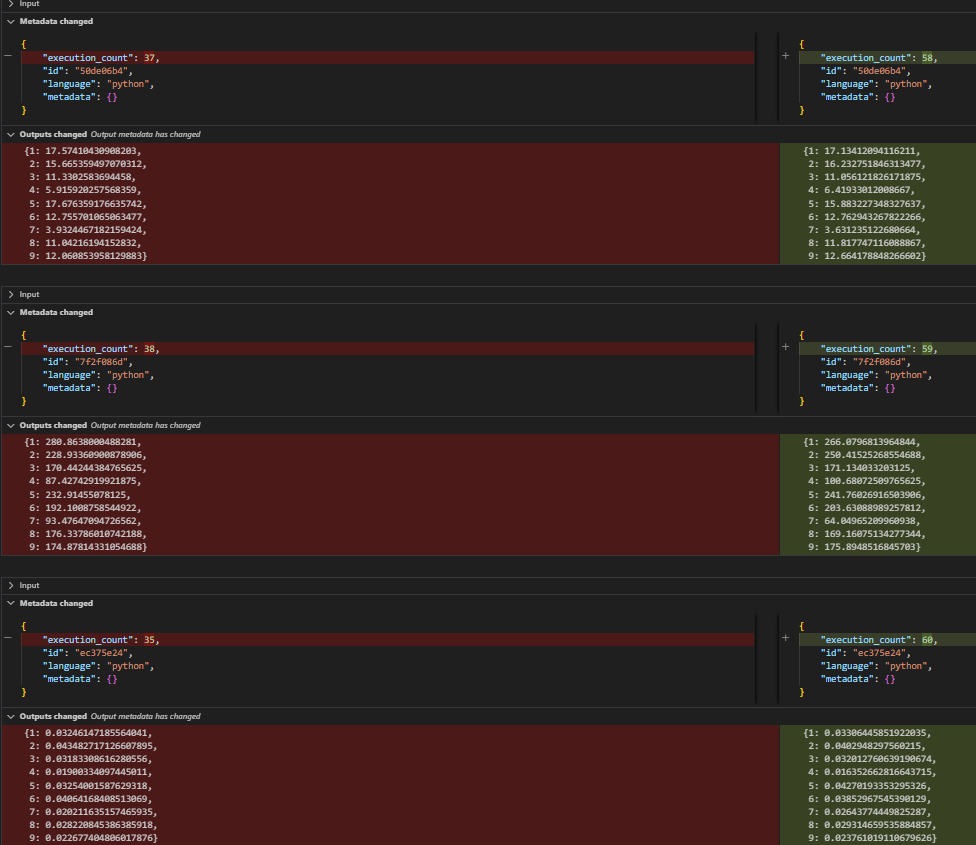

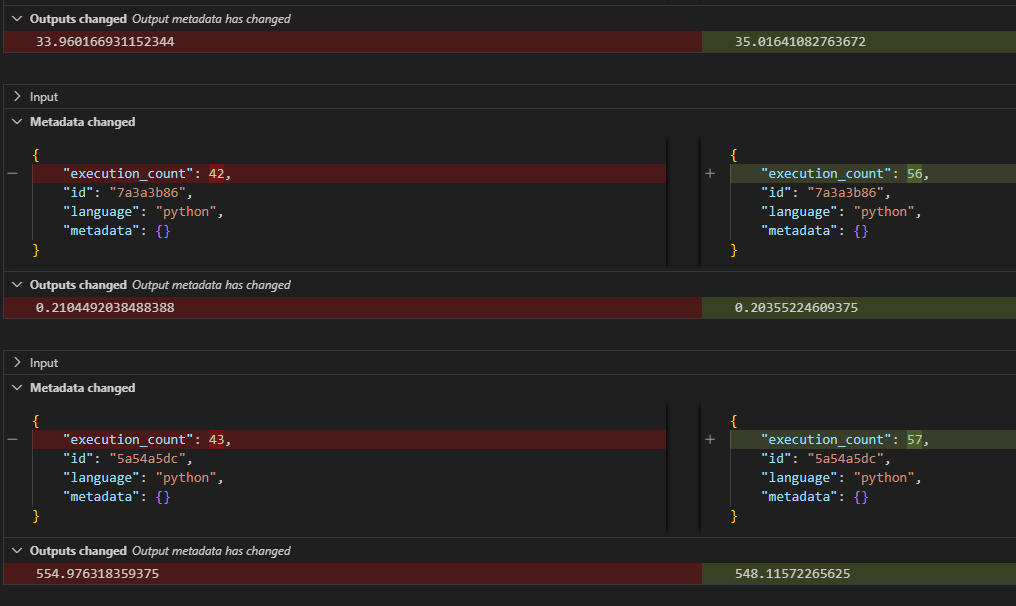